# Epstein Files 

## Introduzione 
Gli [Epstein Files](https://en.wikipedia.org/wiki/Epstein_files) sono i documenti investigativi che riguardano il notorio faccendiere pedofilo Jeffrey Epstein. In totale, i file occupano 300 GB.  

![image](Images/FirsAmendment.jpg)


### Storia e date del rilascio degli Epstein Files

##### Dataset Ufficiali 
Le due principali fonti ufficiali sono: 

-  I documenti rilasciati direttamente dal dipartimento di giustizia seguendo le direttive di [Epstein Files Transparency Act](https://www.congress.gov/bill/119th-congress/house-bill/4405)

-  I documenti richiesti dal congresso. La cronologia del rilascio di questi documenti, per cui non c'è nessun obbligo di renderli pubblici, è ben descritta [qui](https://github.com/markramm/EpsteinFiles/blob/main/DOCUMENT_SOURCES.md)

Molti di questi file sono doppioni. Ecco un'esempio





 DOJ Released                  |   House Released
:---------------------------------:|:-----------------:
 <img src="Images/EFTA01333513.jpg" width="400">  |  <img src="Images/DOJ-OGR-00030902.jpg" width="400">                  


Mentre lavoravo su questo progetto, molti utenti hanno pubblicato programmi e motori di ricerca fatti ad hoc. Uno dei migliori, online e molto esauriente, [è questo](https://epsteingraph.com/)

##### File Rimossi o Censurati

Prima del Epstein Files Transparency Act, ci sono state delle pubblicazioni giornalistiche di alcuni di questi file, che poi sono stati pubblicati nei dataset ufficiali. 

A complicare la faccenda, il fatto che alcuni documenti sono stati pubblicati e poi ritirati, perché (o con la scusa che) alcuni di questi contenevano dati non censurati delle vittime. Esempi di questi dataset sono: 
- Il [dataset 9] (https://www.justice.gov/epstein/doj-disclosures/data-set-9-files) del Dipartimento di Giustizia americano consisteva inizialmente in 180 Gb di files. Per via della presenza di una foto contenente nudi di una vittima è stato ritirato e poi ripubblicato. [La comunità di Reddit](https://www.reddit.com/r/DataHoarder/comments/1qsfv3j/epstein_9_10_11_12_reddit_keeps_nuking_thread_we/) sta cercando di ricreare il dataset
- Un insieme di file presi dai file chiesti e pubblicati dalla Camera statunitense era stato pubblicato su Hugging Faces sotto il nome di [EPSTEIN_FILES_20K](https://huggingface.co/datasets/tensonaut/EPSTEIN_FILES_20K).  Gli autori, per le ragioni espresse in [questo post di Reddit](https://www.reddit.com/r/LocalLLaMA/comments/1p4urm7/we_are_considering_removing_the_epstein_files/), hanno deciso di rimuovere il file. Purtroppo, la maggior parte dei progetti di datascience usavano questo dataset, che comunque è facilmente scaricabile. 

Censura: oltre il ragionevole dubbio della selettività del processo di rilascio dei file, i documenti sono pesantemente censurati per difentere la pivacy delle vittime. 

##### Cercare tra i File

I dati, così come pubblicati dal DoJ e dalla Camera, sono inutilizzabili ai fini di analisi di dati. Diversi parsing che usano algoritmi di riconoscimento visuale sono presenti in rete. U Un'ottimo motore di ricercha che utilizza anche dati ottenuti dal parsing è [questo](https://epsteingraph.com/)

Inoltre, [la pagina github](https://github.com/markramm/EpsteinFiles/blob/main/DOCUMENT_SOURCES.md) già citata in precedenza permette di costruire un motore online. Nel prosimo paragrafo saremo più esaurienti. 


### Galassia di Parser per gli Epstein Files

Vista l'importanza della questione e la natura delle comunity online, uno zoo di metodi e programmi sono stati sviluppati da utenti in modalità open source. In seguito un elenco di una (molto piccola) parte di questi

##### Parser

Diversi tipi di parser sono stati implementati. Questi sono ottimi a dividere i file pubblicati in vari documenti. La maggior parte, oltre a trasformare l'immagine del testo in una stringa, riconosce i nomi propri e li salva. 
Due ottime pagine github sono [questa](https://github.com/markramm/EpsteinFiles) e [questa](https://github.com/actuallyrizzn/epstein-browser)

##### Parser con Riconoscimento Semantico

La maggior parte di questi parser utilizzano algoritmi più avanzati per riconoscere il contesto di una mail, lo scopo. 
Ad esempio [questa](https://github.com/epstein-docs/epstein-docs.github.io) e [questa](https://github.com/maxandrews/Epstein-doc-explorer). (Quest'ultimo dataset, in particolare, è stato utilizzato per fare quello che volevo fare io. In gergo tecnico è detto ["figata  pazzesca"](https://epsteinvisualizer.com/))


##### Ranking 

Un'altra questione è l'ordine con cui andare a leggere i file una volta che sono stati filtrati. Alcune pagine hanno implementato un [motore di ricerca con ranking](https://github.com/latent-variable/epstein-ranker).  

[Questo programma filtra le mail e le ordina in base a un ranking]() (del quale non mi occupo in questo progetto ì)

##### Altre risorse interessanti 

[Le mail di Epstein in formato Gmail (Jmail)](https://jmail.world)

### Scelta del Dataset

Vista la mole di diversi tipi di formato dati, è bene prima porsi la domanda su cosa studiare e poi scegliere il dataset. 

##### Obiettivi per il Report

- Creare un grafo bipartito, dove i nodi di tipo A sono persone e enti, e i nodi di tipo B sono le mail. L'idea iniziale era di plottare il grafo proiettato sui nodi di tip
- Calcolare metriche di grafo: Connettività, gap spettrale... Vedere se queste metriche
- Parte divertente a cui tengo molto: calcolare la curvatura del grafo.

##### Scendere a Patti col Dataset

"Meglio un dataset imperfetto che esiste che un dataset perfetto che non esiste". 

Nonostante nutra dei dubbi sulla fragilità del metodo di parsing delle relazioni, il dataset che più si avvicina ai miei obiettivi è [la già citata pagina github](https://github.com/maxandrews/Epstein-doc-explorer).

Come da descrizione della pagina github, che ricopio sotto, il dataset è composto da 
```sql
-- Documents table
CREATE TABLE documents (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  doc_id TEXT UNIQUE NOT NULL,
  file_path TEXT NOT NULL,
  one_sentence_summary TEXT NOT NULL,      -- AI-generated brief summary
  paragraph_summary TEXT NOT NULL,         -- AI-generated detailed summary
  date_range_earliest TEXT,                -- Earliest date mentioned in document
  date_range_latest TEXT,                  -- Latest date mentioned in document
  category TEXT NOT NULL,                  -- Document category
  content_tags TEXT NOT NULL,              -- JSON array of content tags
  analysis_timestamp TEXT NOT NULL,        -- When analysis was performed
  input_tokens INTEGER,                    -- Claude API usage metrics
  output_tokens INTEGER,
  cache_read_tokens INTEGER,
  cost_usd REAL,                          -- Estimated API cost
  error TEXT,                             -- Error message if analysis failed
  created_at DATETIME DEFAULT CURRENT_TIMESTAMP,
  full_text TEXT                          -- Complete document text for search
);
CREATE INDEX idx_documents_doc_id ON documents(doc_id);
CREATE INDEX idx_documents_category ON documents(category);

-- RDF triples (relationships)
CREATE TABLE rdf_triples (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  doc_id TEXT NOT NULL,
  timestamp TEXT,                         -- When the event occurred
  actor TEXT NOT NULL,                    -- Subject of the relationship
  action TEXT NOT NULL,                   -- Action/verb
  target TEXT NOT NULL,                   -- Object of the relationship
  location TEXT,                          -- Where the event occurred
  actor_likely_type TEXT,                 -- Type of actor (person, organization, etc.)
  triple_tags TEXT,                       -- JSON array of tags
  explicit_topic TEXT,                    -- Explicit subject matter
  implicit_topic TEXT,                    -- Inferred subject matter
  sequence_order INTEGER NOT NULL,        -- Order within document
  top_cluster_ids TEXT,                   -- JSON array of top 3 cluster IDs (materialized)
  created_at DATETIME DEFAULT CURRENT_TIMESTAMP,
  FOREIGN KEY (doc_id) REFERENCES documents(doc_id) ON DELETE CASCADE
);
CREATE INDEX idx_rdf_triples_doc_id ON rdf_triples(doc_id);
CREATE INDEX idx_rdf_triples_actor ON rdf_triples(actor);
CREATE INDEX idx_rdf_triples_timestamp ON rdf_triples(timestamp);
CREATE INDEX idx_top_cluster_ids ON rdf_triples(top_cluster_ids);

-- Entity aliases (deduplication)
CREATE TABLE entity_aliases (
  original_name TEXT PRIMARY KEY,
  canonical_name TEXT NOT NULL,
  reasoning TEXT,                         -- LLM explanation for the merge
  created_at TEXT NOT NULL DEFAULT CURRENT_TIMESTAMP,
  created_by TEXT DEFAULT 'llm_dedupe'    -- Source of the alias
);
```

Vedremo nella sezione di preprocessing che i dati, così come sono, hanno bisogno di pulizia. In particolare, 
-
-
-


In seguito, un esempio di output dei 

Mentre lavoravo sul progetto (2026/02/15) sono usciti altri dataset, alcunni dei quali contengono anche il qullo scelto da me.


Ecco uno stesso documento nel formato rilasciato dalla Camera, dal dipartimento di Giustizia, e i dati che sono presenti di esso nel dataset


 DOJ Released                  |   House Released
:---------------------------------:|:-----------------:
 <img src="Images/EFTA02346130.jpg" width="400">  |  <img src="Images/HOUSE_OVERSIGHT_032390.jpg" width="400">                  
(Una semplice ricerca per data e per nomi porta a [questa notizia]( https://www.nytimes.com/2016/12/12/us/politics/rex-tillerson-secretary-of-state-trump.html) )

In [1]:
###### Dati usati e paragone con gli originali
###### Procediamo ad importare i pacchetti e ad caricare i dati
import sys
import os
import sqlite3 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
import time
import igraph as ig
import time
import random ## To extract a random subgraph
from pyvis.network import Network
import streamlit.components.v1 as components
from itertools import combinations
import re
import getpass
from neo4j import GraphDatabase
import scipy.sparse.linalg as sla
import scipy.sparse as sp


warnings.simplefilter(action='ignore', category=FutureWarning)
#import scipy.sparse as sp

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
import src.my_utils as utl

warnings.simplefilter(action='ignore', category=FutureWarning)



conn = sqlite3.connect('../Data/data.db') #### The path is going to change 

triples = pd.read_sql('SELECT * FROM rdf_triples', conn)
documents = pd.read_sql('SELECT * FROM documents', conn)  ### Here Maybe we Wish to Select the columns that we actually use
aliases = pd.read_sql('SELECT * FROM entity_aliases',conn)

conn.close()


In [2]:
utl.stampa_info_doc(documents, triples, 'HOUSE_OVERSIGHT_032390', text = True)
#utl.stampa_info_doc(documents, triples, 'HOUSE_OVERSIGHT_011280', text = True)
#documents['doc_id'].loc[30]


===================== DOCUMENT ID: HOUSE_OVERSIGHT_032390 ======================

SUMMARY:
An email exchange between Tom Pritzker and Jeffrey Epstein regarding weather, travel plans to Aspen, and commentary on Rex Tillerson's appointment as Secretary of State.

METADATA:
 • Category:   email
 • Date Range: 2016-12-15T08:53:00 to 2016-12-15T15:54:53

------------------------------- PARSED RELATIONS -------------------------------

Found 4 semantic relations (Actor → Action → Target):

.................................. Relation 1 ..................................
 ▶ Jeffrey Epstein sent email to Tom Pritzker
   Location: None
   Tags:     ["email_communication","personal_correspondence","minimal_content_message"]
   Explicit: minimal message exchange with query marker
   Implicit: routine correspondence between contacts

.................................. Relation 2 ..................................
 ▶ Tom Pritzker sent email to Jeffrey Epstein
   Location: None
   Tags:     ["email_


## Obiettivi 

Altri grafi possono essere trovati [qui](https://epstein-file-explorer.com/network), [qui](https://epsteingraph.com/) e [qui](), gli ultimi due già studiati precedentemente. 

##### Progetti Futuri

- Pesare i legami in base al loro valore semantico 

- Mantenere un dataset con i rilasci ufficiali e non, di documenti in formato leggibile dal calcolatore, insieme ai documenti rilasciati, mantenendo un legame con i file originali. Inoltre, mantenere un campo che punta ai duplicati, così da poter facilmente rimuovere i duplicati mantenendo la struttura dei dataset originali, nella forma in cui sono stati rilasciati 
(Purtroppo la gente non capisce che rendere riproducibili i risultati è l'80% del lavoro. Ci ho messo 4 ore a capire che i file parsati [qui](https://github.com/epstein-docs/epstein-docs.github.io) provenissero dai [Documenti della Corte Federale statunitense](https://drive.google.com/drive/folders/1TrGxDGQLDLZu1vvvZDBAh-e7wN3y6Hoz) )

- Migliorare il parsing, soprattutto la parte semantica, per renderlo più adatto al nostro scopo

- Applicare tutto ai Panama Papers


## Problemi 

- Granularità: I dati non sono uniformi: mentre alcuni sono dei documenti originali interi, altri sono le pagine di questi. Non è chiaro come pesare ciascun documento. Nel primo caso, infatti, si da uguale peso a documenti grandi e piccoli, mentre, nel secondo si da più peso ai documenti più grandi. In realtà il nostro punto di riferimento sono le relazioni semantiche ottenute, che a meno di frasi scritte su più pagine, non dipendono dalla granularità.
- Come mostreremo nell'analisi esplorativa dei dati, molti dati sono inconsistenti.
- 

##### Temporary section
1) Data and safety check 
I want to first see whether the datasets [questa](https://github.com/epstein-docs/epstein-docs.github.io) e [questa](https://github.com/maxandrews/Epstein-doc-explorer) overlap. I prefer the first one, but it onlty has court case. Maybe I can put both of them as a safety check that the parsing is not mad, comparing the true document wth the parsed ones in both cases. However, the first dataset is anoyingly ill named and id does not have a document _id. 

2) Upload of the data and definition of the graph structure

3) Usual gaph statistic , for sure there is some python library. 

4) Defiition of the dual graph (or maybe the bipartite, if this is the case, I shall do it before)

5) Same metrics on the graph whose nodes are emails. I think it is useful to see how information travels

6) The best part, the curvature of the graph

Questions: How .should I treat the time??????

7) Visualization: I will recycle the visualizator of the folder, which is already super cool 

## Exploratory Data Analysis (EDA) E pre

L'EDA è un processo iterativo, dato che molte delle inconsistenze e difformità vengono trovate solo durante il processo di visualizzazione. Noi mostriamo solo il risultato di queste iterazioni.

#### Consistenza 

Dapprima, deduplichiamo i nomi, che, durante il parsing, sono stati riconosciuti in diverse form, e.g., "Epstein", "Jeff", "Jeffrey"..

Dopo procediamo a fare un'analisi di consistenza, nella quale vediamo che ci sono delle relazioni semantiche trovate in un documento non presente nel dataset, e cioé il documento 'HOUSE_OVERSIGHT_013343'. [Una ricerca in rete](https://epsteingraph.com/documents/HOUSE_OVERSIGHT_013343) ci fa vedere che le relazioni semantiche sono concordi con il documento, che provvediamo ad aggiungere al dataset. 

Dopodiché filtriamo i documenti che effettivamente hanno dato luogo a relazioni semantiche. Questi sono errori, documenti pesantemente censurati, e pagine vuote di documenti più lunghi. 

#### Deduplicazione

Nel dataset sono presenti dei duplicati "soft", che sono stati scoperti in un secondo momento tramite l'analisi degli outlier della statistica "information_density". Questi sono documenti che hanno dato origine ai documenti, e che li contenevano in formato .txt. In altre parole, sono i file che sono stati processati per dare origine ai diversi documenti. 

Li rimuoviamo facilmente dai documenti, e filtriamo anche le relazioni semantiche assocuate a questi. Per fortuna, dall'id di questi documenti, finiti per errore, possiamo possiamo ricavare il loro duplicato e verificare che effettivamente stiamo rimuovendo duplicati

#### Pulizia e Visualizzazione

Da un'analisi visiva e individuale dei documenti, rimuoviamo i documenti il cui testo è inferiore ai 100 caratteri e le loro relazioni semantiche associate. 

Visualizziamo la quantità di documenti presenti per categoria, le triple semantiche per documento e per argomento esplicito. 

Visualizziamo la distribuzione delle lunghezze dei documenti e del numero di relazioni semantiche associate. Plottiamo, poi, la distribuzione congiunta di variabili della lunghezza del documento vs  numero di triple semantiche ottenute. 

Infine, definiamo la densità di informazione come il numero di triple semantiche ottenute per 100 caratteri. Verifichiamo che la densità di informazione dipende dalla grandezza dei documenti considerati. Più precisamente, fissiamo una sogla treshold (= 2000) e verifichiamo che la densità di informazione dei diversi documenti con un numero maggiore di caratteri della soglia ha una distribuzione empirica a doppia buca. Verifichiamo che questo comportamento e spiegato da un diverso comportamento della variabile "information_density" rispetto alla categoria di documenti. 

Ipotizziamo, forti dello scatterplot 'lunghezza del documenti (in caratter) vs numero di triple semantiche', che questo è dovuto a una serie di documenti, in formato di libro o di report, che contengono un gran numero di caratteri e per cui il numero di relazioni parsate non cresce di pari passo (in sostanza, danno origine a poche triple semantiche)

(Più probabilmente dovrei definire la variabile log(densita + 1), ma lo farò in futuro)



In [3]:
#------- PULIZIA PRELIMINARE-----------------------------------------------------
## DEDUPLICAZIONE, INCONSISTENZE E FILTRAGGIO:
##
# Deduplichiamo gli alias con cui lo stesso nome è conosciuto
# e.g., 'Epstein' -> 'Jeffrey Epstein'.
# 
print(25*'-' +' DEDUPLICAZIONE ' + 25*'-')
print('Deduplichiamo i nomi canonicizzando i diversi alias')
alias_dict = dict(zip(aliases["original_name"], aliases["canonical_name"])) #Alias dictionary
triples['actor'] = triples['actor'].map(alias_dict).fillna(triples['actor']) # notice that .map is much faster than .replace
triples['target'] =triples['target'].map(alias_dict).fillna(triples['target'])
print('Deduplicazione completa \n*')

#
##
##
#Cerchiamo NA nella colonna dei doc_ids 
n_nan_documents = sum(documents['doc_id'].isna())
n_nan_triples = sum(documents['doc_id'].isna())
print('Controlliamo i NaN nella colonna doc_id')
print(f'Nella colonna doc_id di documents sono presenti {n_nan_documents} Not a Number')
print(f'Nella colonna doc_id di triples sono presenti {n_nan_triples} Not a Number')
print('*')
##
are_there_duplicates = documents['doc_id'].duplicated()
print('Ci sono doc_id uguali documenti duplicati? ')
print(f'There are {sum(are_there_duplicates)} rows that share the same doc_id')
print( 'Purtroppo, ci sono documenti \033[1mduplicati di file con doc_id\033[0m, come vedremo dopo \n*')
##
## Consistenza dei dati tra i due dataframe 
##
#Primo filtraggio
print('Filtriamo il dataframe documents prendendo solo \ni documenti da cui sono state ottenute relazioni semantiche')
print('Molti di questi sono errori o pagine finali di documenti più larghi\n')
doc_ids_triples = triples['doc_id'].unique()
set_doc_ids_triples = set(doc_ids_triples)
documents = documents[documents['doc_id'].isin(set_doc_ids_triples)]
doc_ids = documents['doc_id'].unique()
set_doc_ids = set(doc_ids)
print('\033[1mC\'è un\inconsistenza nel dataset! \033[0m')
print(f'The number of different documents present in the table doc: {len(doc_ids)}')
print(f'The number of different documents present in the table triples: {len(doc_ids_triples)}')
print('c\'è un documento da cui sono state ottenute triple semantiche che non è inserito nella lista dei documenti\n')
print(f'Il documento è {set_doc_ids_triples - set_doc_ids} \n\033[1mNotaì: se la cella viene runnata una seconda volta, l\'inconsistenza sparisce\033[0m\n')
print('Il documento può essere trovato quì https://epsteingraph.com/documents/HOUSE_OVERSIGHT_013343')
print('Un\'occhiata al documento precedente mostra che le relazioni parsate da esso sono giuste ')
print('Decidiamo tenerlo')
print('***** Inseriamo a mano il documento*****\n\n')
category_documento_perso = documents[ documents['doc_id'] =='HOUSE_OVERSIGHT_013341']['category'].iloc[0]
print(category_documento_perso)
documento_perso = {
    'doc_id':  'HOUSE_OVERSIGHT_013343', 
    'category': 'report',# A research online shows that froom HOUSE_OVERSIGHT_013319 is the sam document, and it is saved here as a report
    'one_sentence_summary': 'Page summarizes allegations that Brunel and the modeling agency MC2, affiliated with Epstein, recruited, housed, and arranged visas for underage girls, reports Brunel visited Epstein in jail approximately 67 times, and cites a June 15, 2010 sworn statement by Maritza Vasquez.',
    'full_text': 'Edwards that Brunel might have been procuring two eight-year-old girls for Epstein to sexuallyabuse. According to widely circulated press reports reviewed by Edwards, Brunel is in his sixties and has a reputation throughout the world (and especially in the modeling industry) as a I addict that has for years molested children through modeling agencies while acting as their agent — conduct that has been the subject of critical reports, books, several news articles and a 60 Minutes documentary on Brunel’s sexual exploitation of underage models. See http://bradmillershero.blogspot.com/2010/08/women-are-objects.html, attached hereto as Exhibit \n “FE.”\n63. Edwards learned that Brumel is also someone that visited Epstein on approximately 67 occasions while Epstein was in jail. See Epstein\'s jail visitor log attached as nd “GG.”\n 64. Edwards learned that Brunel currently runs the modeling agency MC2, a company for which Epstein provides financial support. See Message Pad\'s attached as Exhibit “J” supra Sworn Statement of MC2 employee Maritza Vasquez, June 15, 2010, “Maritza Vasquez Sworn Statement” attached at Exhibit “HH” at 1-16.\n 65. Employees of MC2 told Edwards that Epstein’s numerous condos at 301 East 66 Street in New York were used to house young models. Edwards was told that MC2 modeling agency, affiliated with Epstein and Brunel brought underage girls from all over the world, promising them modeling contracts. Epstein and Brunel would then obtain a visa for these girls, then would charge the underage girls rent, presumably to live as underage prostitutes in the condos. See Maritza Vasquez Sworn Statement, Exhibit “HH” at 7-10, 12-15, 29-30, 39-41, 59-60 and 62-67.\n 25\n HOUSE_OVERSIGHT_013343', 
}
new_row_df = pd.DataFrame([documento_perso])
documents = pd.concat([documents, new_row_df], ignore_index=True)
## The document is not present, but it can be found here. As the 
## https://epsteingraph.com/documents/HOUSE_OVERSIGHT_013343
utl.stampa_info_doc(documents, triples, 'HOUSE_OVERSIGHT_013343') # La funzione stampa è stata modificata per permettere a questo documento di essere plottatp
print('Documento inserito manualmente\n Se il programma gira di nuovo, l\'inconsistenza sparisce \n*')


##
## Un'ulteriore inconsistenza: I documenti da seguenti ID, 
## sono pagine di uno stesso documento, ma la categoria non è la stessa
start_id = 'HOUSE_OVERSIGHT_013319'
end_id = 'HOUSE_OVERSIGHT_013343'

# This creates a new dataframe with only the documents in that range
subset_df = documents[documents['doc_id'].between(start_id, end_id)].copy()
print(f'\033[1mUn\'ulteriore inconsistenza che non correggerem\033[0m: i documenti da {start_id} a {end_id} sono pagine di uno stesso documento')
print('Ma la categoria sotto le quali sono segnate varia. Dovrebbe essere un court filing')
print(subset_df['category'].unique())
####
#### Seconda deduplicazione 
####
##
## 
## Scegliamo i documenti cha hanno dato origine al parsin
####
#### ALTRA FILTRI SUI DOCUMENTI 
#### 
print(25*'-' + ' Filtro Documenti' + 25*'-')
# La pulizia consiste in 
# Hard deduplicates: NO
# Soft deduplicates: A LOT (Scoperti studiando outlier)
# Documenti senza Parsing
# Documenti brevi

print('Molti documenti contengono soft duplicates iniziano con la dicitura TEXT-001- o la dicitura TEXR-002-')
print('Sembrerebbero collezioni di diversi documenti e sono stati parsati per errore probabilmente')
print('Sono stati scoperti durante la fase di controllo degli outlier nella statistica dennsità di informazione')
print('Procediamo ad analizzarli e rimuoverli')
## These are the documents that we want to check if needed to  remove
## They were discovered by an outlier analysis on the statistic "density of information"

## Now we want to check how many of them are duplicates
pattern = r'^TEXT-\d+-(.*)'
documents['real_id_potential'] = documents['doc_id'].str.extract(pattern) # Mi ritorna NA se il doc_id non iniziava per TEXT

set_possible_duplicates = set(documents['real_id_potential'].dropna()) # L'insieme dei doc_id che inizia con TEXT
condition = documents['doc_id'].isin(set_possible_duplicates) # Condizione: I documenti che non sono doppioni di un TEXT
set_duplicates = set(documents[condition]['doc_id']) # L'insieme dei doc_id che hanno un TEXT-001- o TEXT-002 
#print(set_possible_duplicates)
print(f'Il numero di documenti che iniziano per TEXT- è: {len(set_possible_duplicates)}')
print(f'Il numero di questi che sono doppioni  {len(set_duplicates)}')
print(f'Ne restano {len( set_possible_duplicates - set_duplicates)}. \n\033[1m Nota\033[0m, se le celle vengono runnate una seconda volta, il risultato cambia')
print( 'Li andiamo a stampare')
print('Un\'analisi visiva e grossolana di questi documenti rivela che ')
print('si tratta di documenti che contengono al suo interno diversi documenti')
print('Quindi il nome è sbagliato e sono finiti la probabilmente per errore')
print('\033[1m Eliminiamo\033[0m dunque questi documenti, e le relazioni semantiche associate')

# Filtriamo i due dataset
condition = documents['real_id_potential'].isna()
documents = documents[condition]
triples = triples[ triples['doc_id'].isin(documents['doc_id'])]
#for doc in documents[documets]:
#    print(doc)
    #doc_name = doc['doc_id'].loc[0]
    #doc_text = doc['full_text'].loc[0]
    #print(25*'-' + doc_name  + 25*'-')
    #print(80*'*' + '\n')
    #print(doc_text)

# Un ultimo filtro 

treshold = 80 ## Il motivo di scegliere questa soglia è una lettura manuale dei vari documenti droppati 
print('Primo filtro: Eliminiamo i documenti con pochi caratteri.')
print(f'Fissiamo una soglia {treshold} di caratteri minima')
print('sotto la quale, eliminiamo il documento. La scelta del valore')
print(f'{treshold} è dettata da una lettura dei documenti droppati')
condition1 = documents['full_text'].str.len() > treshold
print(f'Abbiamo trovato {sum(~condition1)} documenti con meno di {treshold} caratteri')
print('\033[1m Eliminiamo\033[0m dunque questi documenti, e le relazioni semantiche associate')
print(80*'*' + '\n '+ 80*'*' + '\n')

documents = documents[condition1]
triples = triples[triples['doc_id'].isin(set(documents['doc_id']))]


------------------------- DEDUPLICAZIONE -------------------------
Deduplichiamo i nomi canonicizzando i diversi alias
Deduplicazione completa 
*
Controlliamo i NaN nella colonna doc_id
Nella colonna doc_id di documents sono presenti 0 Not a Number
Nella colonna doc_id di triples sono presenti 0 Not a Number
*
Ci sono doc_id uguali documenti duplicati? 
There are 0 rows that share the same doc_id
Purtroppo, ci sono documenti duplicati di file con doc_id, come vedremo dopo 
*
Filtriamo il dataframe documents prendendo solo 
i documenti da cui sono state ottenute relazioni semantiche
Molti di questi sono errori o pagine finali di documenti più larghi

C'è un\inconsistenza nel dataset! 
The number of different documents present in the table doc: 18125
The number of different documents present in the table triples: 18126
c'è un documento da cui sono state ottenute triple semantiche che non è inserito nella lista dei documenti

Il documento è {'HOUSE_OVERSIGHT_013343'} 
Notaì: se la cella v

In [4]:
#### Un problema riscontrato lungo il corso dell'analisi è che, delle volte, l'attore o il targed
#### è un documento. Un'ispezione manuale mostra che tali documenti sono il più delle volte interessanti, e decidiamo 
#### quindi di tenerli, e di rimuovere tali documenti dal target (actor) e inserire come nuovo target (attore) l'attore (target) della stessa relazioe semantica, creando un self-loop
#### Lasciamo per il futuro un'analisi sui nodi di persone non identificate, che per ora sono trattate come lo stesso nodo 
t0 = time.time()

# 1. Use a SET for O(1) instant lookups (Do NOT use a list)
all_docs_set = set(documents['doc_id'].unique())

# 2. The High-Speed Lookup Function
def contains_doc_fast(text):
    if not isinstance(text, str):
        return False
    
    # Check 1: Is it an exact match? (Instant)
    if text in all_docs_set:
        return True
        
    # Check 2: Is it buried in the text? e.g., "document HOUSE_OVERSIGHT_123"  !!!!Questo mi fa cancellare ignoti che forse sono importanti!!!!
    # We strip punctuation and split by spaces to check each word instantly
#    clean_text = re.sub(r'[^\w\s-]', ' ', text)
#    for word in clean_text.split():
#        if word in all_docs_set:
#            return True           
    return False

# 3. Apply the lightning-fast masks
print("Generating masks...")
mask_actor_doc = triples['actor'].apply(contains_doc_fast)
mask_target_doc = triples['target'].apply(contains_doc_fast)

# 4. Handle "Both are Docs" case
mask_both = mask_actor_doc & mask_target_doc
triples_to_delete = triples[mask_both]

if not triples_to_delete.empty:
    print(f"\n--- ELIMINATING {len(triples_to_delete)} RELATIONS (Both are Docs) ---")
    for _, row in triples_to_delete.iterrows():
        print(f"Eliminated: [{row['actor']}] & [{row['target']}] in {row['doc_id']}")

# Keep the valid/fixable triples
triples = triples[~mask_both].copy()
mask_actor_doc = mask_actor_doc[~mask_both]
mask_target_doc = mask_target_doc[~mask_both]

# 5. Attori rimpiazzati con target
mask_only_actor = mask_actor_doc & ~mask_target_doc
print(f"\n--- FIXING ACTORS ({mask_only_actor.sum()} relations) ---")
for idx, row in triples[mask_only_actor].iterrows():
    # Print a few examples just to verify, avoid printing thousands
    if idx % max(1, (mask_only_actor.sum() // 5)) == 0: 
        print(f"Sample Fix: Actor '{row['actor']}' replaced with '{row['target']}'")
    triples.at[idx, 'actor'] = row['target']

# Target rimpiazzati con attori 
mask_only_target = mask_target_doc & ~mask_actor_doc
print(f"\n--- FIXING TARGETS ({mask_only_target.sum()} relations) ---")
for idx, row in triples[mask_only_target].iterrows():
    if idx % max(1, (mask_only_target.sum() // 5)) == 0:
        print(f"Sample Fix: Target '{row['target']}' replaced with '{row['actor']}' in document '{row['doc_id']}'")
    triples.at[idx, 'target'] = row['actor']

t1 = time.time()

print(f"\nCleaned and Transformed in {t1 - t0:.2f} seconds! Final count: {len(triples)}")


##### 
answer = len(triples["doc_id"].unique()) != len(documents)
print(f'Have we eliminated all the relation parsed from some document? {answer}')
if  not answer: 
    print('Then we do not have to remove any document')


#### We add the url's to the files 
# Creates the URL by sticking the base link and the doc_id together
documents['url'] = 'https://epsteingraph.com/documents/' + documents['doc_id'].astype(str)

for url in documents['url'].head():
    print(url)

Generating masks...

--- FIXING ACTORS (0 relations) ---

--- FIXING TARGETS (54 relations) ---
Sample Fix: Target 'HOUSE_OVERSIGHT_010734' replaced with 'Kenneth W. Starr' in document 'HOUSE_OVERSIGHT_010734'
Sample Fix: Target 'HOUSE_OVERSIGHT_017065' replaced with 'Jim Breyer' in document 'HOUSE_OVERSIGHT_017065'
Sample Fix: Target 'HOUSE_OVERSIGHT_030879' replaced with 'Richard Kahn' in document 'HOUSE_OVERSIGHT_030879'
Sample Fix: Target 'HOUSE_OVERSIGHT_014236' replaced with 'Giuffre' in document 'HOUSE_OVERSIGHT_014236'

Cleaned and Transformed in 0.24 seconds! Final count: 92058
Have we eliminated all the relation parsed from some document? False
Then we do not have to remove any document
https://epsteingraph.com/documents/HOUSE_OVERSIGHT_010477
https://epsteingraph.com/documents/HOUSE_OVERSIGHT_010486_part1
https://epsteingraph.com/documents/HOUSE_OVERSIGHT_010486_part2
https://epsteingraph.com/documents/HOUSE_OVERSIGHT_010560
https://epsteingraph.com/documents/HOUSE_OVERSIGHT


------------------------- Fundamental Quantities-------------------------

Il numero di documenti è: 15692
Il numero di triple è: 92058


 * Il  numero di documenti per categoria 

category
email                 4209
report                2814
book_excerpt          2293
media_article         1695
transcript            1127
financial_document     805
court_filing           667
mixed_document         583
memorandum             400
other                  369
Name: doc_id, dtype: int64

 * Il numero di documenti per lunghezza (in unità di 100 caratteri):
Notare che molti documenti sono pagine di documenti più grandi



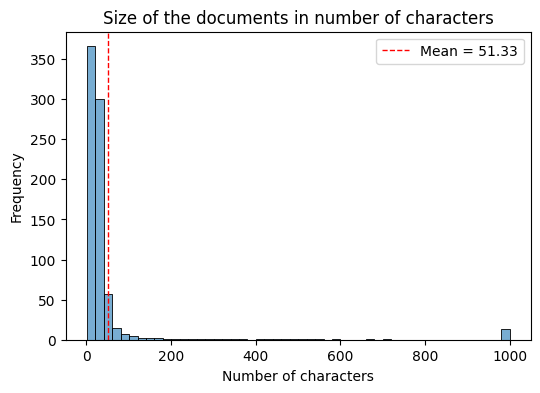


*Vediamo come cambia la distribuzione delle lunghezze considerando le seguenti diverse categorie ['email', 'book_excerpt']


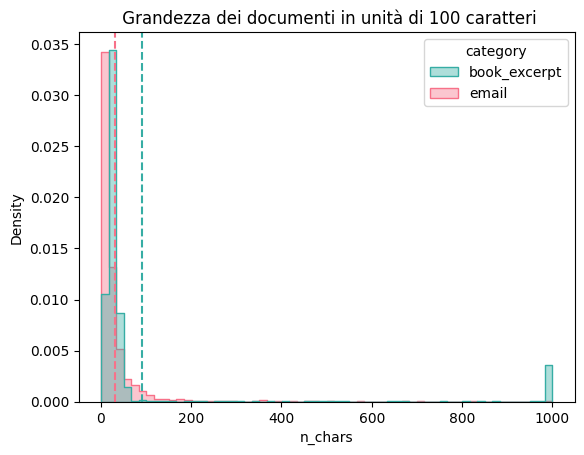

Notiamo che la distribuzione dei frammenti di libri sembra essere, a differenza della distribuzione della lunghezza delle mail, distribuita come la somma di due delta, con molti libri molto poco lunghi e un cluster di estratti di libri di 100000 caratteri. Probabilmente questi sono frammenti di un unico libro più grande, ma evitiamo di indagare ulteriormente.

* Numero di triple per documento: 

The number of triples per document

doc_id
HOUSE_OVERSIGHT_017088_part7    107
HOUSE_OVERSIGHT_027594          107
HOUSE_OVERSIGHT_027460          103
HOUSE_OVERSIGHT_022445           85
HOUSE_OVERSIGHT_017088_part4     79
HOUSE_OVERSIGHT_025452           75
HOUSE_OVERSIGHT_020447_part1     70
HOUSE_OVERSIGHT_027165           69
HOUSE_OVERSIGHT_025707           67
HOUSE_OVERSIGHT_023627           67
dtype: int64

* Numero di triple per explicit_topic: 
explicit_topic
confidentiality and privilege notice       106
biographical death notice                   98
ownership interest documentation   

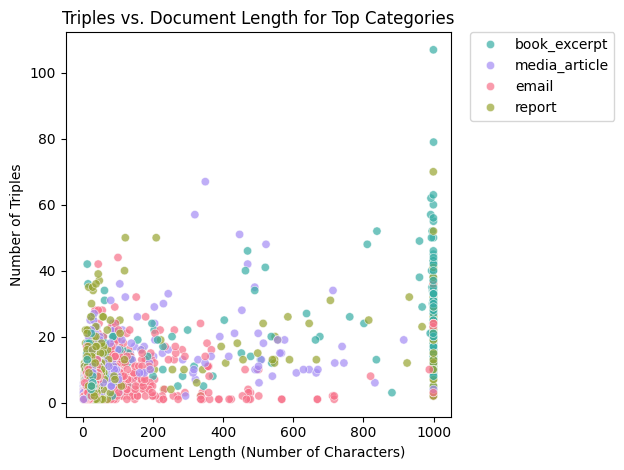

In [5]:
### PRIMA VISUALIZZAZIONE
n_documents = len(documents)
n_triples = len(triples)
print('\n' + 25*'-' +' Fundamental Quantities' +25*'-'  + '\n')
print(f'Il numero di documenti è: {n_documents}')
print(f'Il numero di triple è: {n_triples}\n')

# Documenti per gruppo. Categoria
print('\n * Il  numero di documenti per categoria \n')
print(documents.groupby('category')['doc_id'].count().sort_values(ascending = False).head(10))

# Numero di documenti per lunghezza
print('\n * Il numero di documenti per lunghezza (in unità di 100 caratteri):')
print('Notare che molti documenti sono pagine di documenti più grandi\n')

documents['n_chars'] = documents['full_text'].str.len()/100 # Nuova colonna con la statistica del numero di carateri 

mean_value = documents['n_chars'].mean()
n_bins = 50

plt.figure(figsize=(6,4))
sns.histplot(documents['n_chars'], bins = n_bins, stat = 'frequency', alpha = 0.6)
plt.axvline(mean_value, color='red', linestyle='--', linewidth=1, label=f'Mean = {mean_value:.2f}')
# Labels and title
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.title(f'Size of the documents in number of characters')
plt.legend()
plt.show()

## Tavolazza di colori da usare sempre in  futurp
n_top_categories = 4
top_categories = (
    documents['category']
      .value_counts()
      .head(n_top_categories)
      .index
      .tolist()
) 
colors = sns.color_palette("husl", n_top_categories).as_hex()
category_colors = dict(zip(top_categories, colors))

categorie = ['email', 'book_excerpt']
print(f'\n*Vediamo come cambia la distribuzione delle lunghezze considerando le seguenti diverse categorie {categorie}')

mask = documents['category'].isin(categorie)

doc_plot = documents[mask]
n_bins = 60

sns.histplot(
    data=doc_plot, 
    x='n_chars', 
    hue='category',     # This separates the data by category
    bins=n_bins, 
    palette = category_colors, 
    element="step",     # 'step' or 'poly' makes overlaps easier to see
    stat='density',
    common_norm = False, 
    alpha=0.4,
)

for cat in categorie:
    # Calculate mean for this specific category
    cat_mean = documents[documents['category'] == cat]['n_chars'].mean()
    
    # Get the color from our dictionary
    line_color = category_colors.get(cat)
    
    plt.axvline(
        x=cat_mean, 
        color=line_color, 
        linestyle='--', 
        linewidth=1.5,
        label=f'Mean {cat}' # Optional: this might make the legend very long
    )

plt.title(f" Grandezza dei documenti in unità di 100 caratteri")
plt.show()
print('Notiamo che la distribuzione dei frammenti di libri sembra essere, a differenza della distribuzione della lunghezza delle mail, distribuita come la somma di due delta, con molti libri molto poco lunghi e un cluster di estratti di libri di 100000 caratteri. Probabilmente questi sono frammenti di un unico libro più grande, ma evitiamo di indagare ulteriormente.')

# Numero di triple per documento 
print('\n* Numero di triple per documento: ')
reference_counts = (
    triples.groupby('doc_id')
      .size()
      .rename('n_triples')
      .reset_index()
)
documents = documents.merge( # Nota, se runnato 2 volte il nome della colonna viene cambiato
    reference_counts,
    left_on='doc_id',
    right_on='doc_id',
    how='left'
).fillna(0) # Nuova colonna con il numero di triple per ogni documento
print('\nThe number of triples per document\n')
print(triples.groupby('doc_id').size().sort_values(ascending = False).head(10))

# numero di triple per explicit_topic
print('\n* Numero di triple per explicit_topic: ')
print(triples.groupby('explicit_topic').size().sort_values(ascending = False).head(10))

#numero di triple per explicit_topic
print('\n* Numero di triple per implicit_topic: ')
print(triples.groupby('implicit_topic').size().sort_values(ascending = False).head(10))



doc_plot = documents[documents['category'].isin(top_categories)] 
sns.scatterplot(
    data=doc_plot,
    x='n_chars',
    y='n_triples',
    hue='category',             # 👈 Colors by category
    palette=category_colors,  # 👈 Plug in your existing palette variable here!
    alpha=0.7                   # 👈 Makes dots slightly transparent so you can see overlaps
)

plt.xlabel('Document Length (Number of Characters)')
plt.ylabel('Number of Triples')
plt.title('Triples vs. Document Length for Top Categories')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout() 
plt.show()


------------------------- Bimodalità Densità di Informazione-------------------------

Mostriamo che la densità di informazione ha due comportamenti diversi e non è costante 
    rispetto al numero di caratter di un documento
     
Più precisamente, se consideriamo documenti con un numero di caratteri 
    maggiori di una soglia t, allora la media della densità di informazione decresce.
     
Se da un lato questo è normale, verifichiamo che questa decrescita dell'informazione 
    non è uniforme lung i gruppi e che da origine ad una distribuzione bimodale della densità 
    di informazione nei documenti
     
Ipotizziamo, forti dei grafici, che questo fenomeno è dovuto a un cluster di documenti che sono di categoria "book_excerpt". Non indaghiamo oltre, ma questo diverso comportamento è dovuto al cluster di
    questo tipo di documento, che si vede nello scatter plot, di poca informazione e gran numero di caratteri. Probabilmente sono pezzi di uno stesso libro più grande, che quindi vi

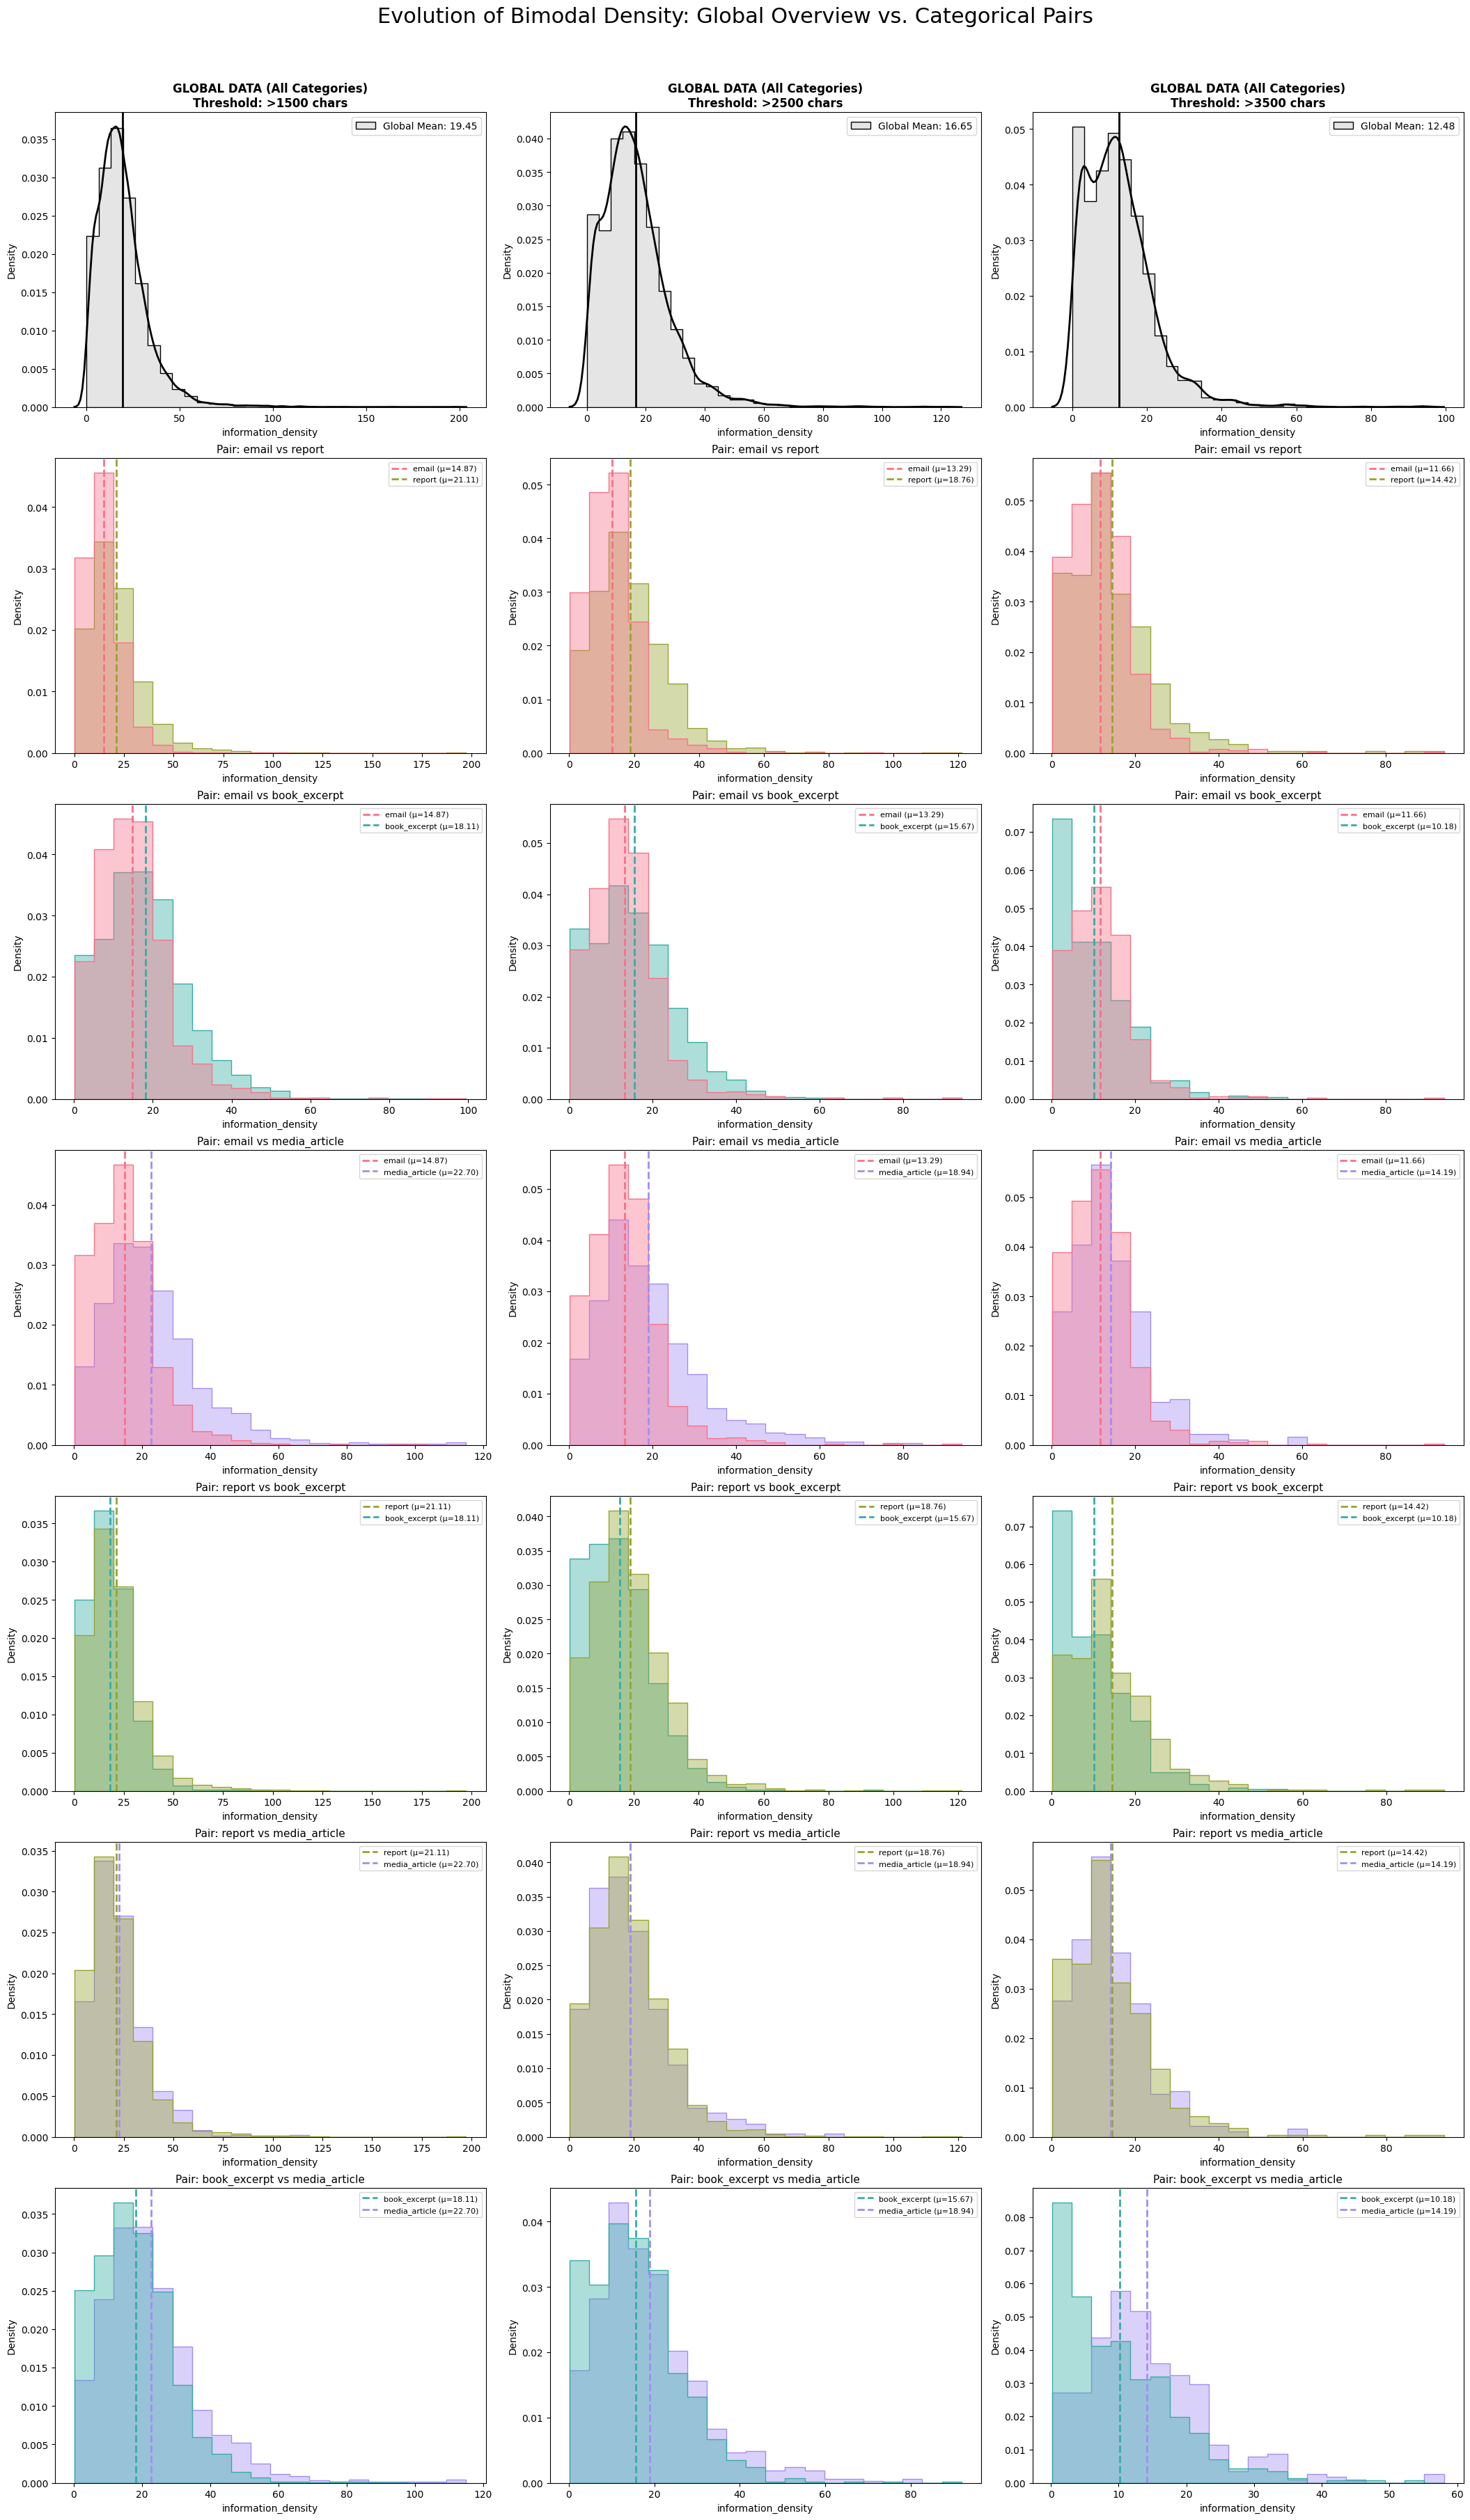

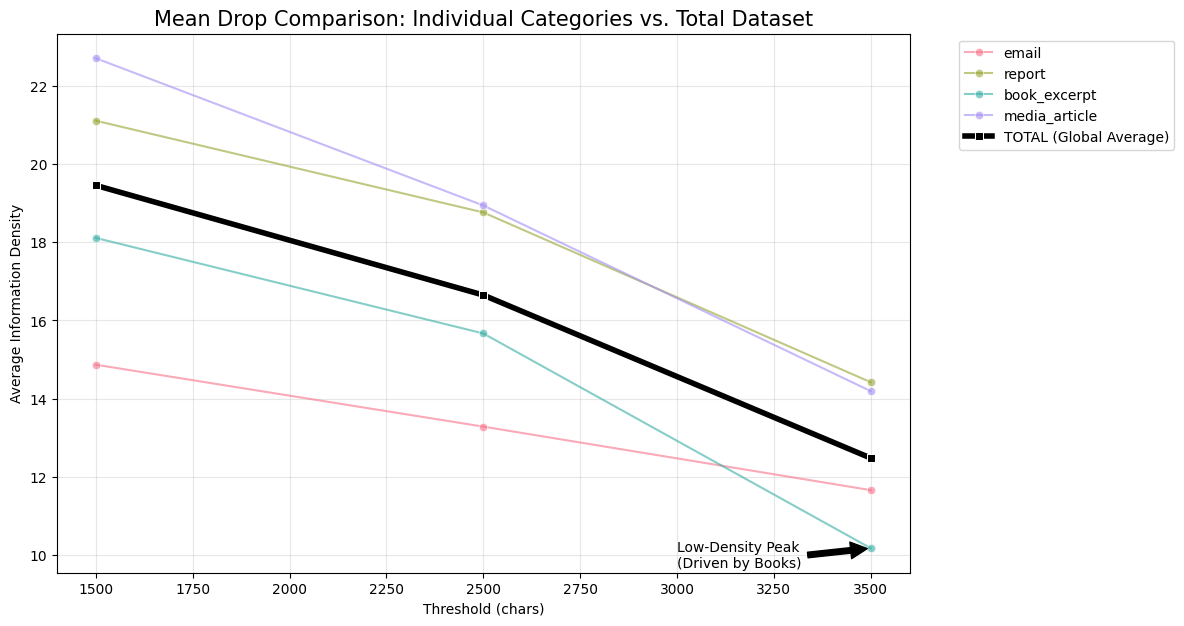

In [6]:
print(25*'-' + ' Bimodalità Densità di Informazione' + 25*'-' + '\n')
print('''Mostriamo che la densità di informazione ha due comportamenti diversi e non è costante 
    rispetto al numero di caratter di un documento
     ''')
print('''Più precisamente, se consideriamo documenti con un numero di caratteri 
    maggiori di una soglia t, allora la media della densità di informazione decresce.
     ''')
print('''Se da un lato questo è normale, verifichiamo che questa decrescita dell\'informazione 
    non è uniforme lung i gruppi e che da origine ad una distribuzione bimodale della densità 
    di informazione nei documenti
     ''')
print('''Ipotizziamo, forti dei grafici, che questo fenomeno è dovuto a un cluster di documenti che sono di categoria "book_excerpt". Non indaghiamo oltre, ma questo diverso comportamento è dovuto al cluster di
    questo tipo di documento, che si vede nello scatter plot, di poca informazione e gran numero di caratteri. Probabilmente sono pezzi di uno stesso libro più grande, che quindi viene pesato troppo nell\'istogramma, ma non indaghiamo oltre.
     ''')
thresholds = [15,25,35] ## n_char è in unità di 1000 caratteri. 
# Andiamo a filtrare i docuumenti con meno di 1000, 2000, e 3000 caratteri 
documents['information_density'] = 100*documents['n_triples']/(documents['n_chars']+1)


# 1. Setup dimensions
coppie_categorie = list(combinations(top_categories, 2))
n_rows_pairs = len(coppie_categorie)
n_rows_total = n_rows_pairs + 1 # +1 for the Global Row at the top
n_cols = len(thresholds)

fig, axes = plt.subplots(n_rows_total, n_cols, figsize=(7 * n_cols, 5 * n_rows_total), constrained_layout=True)

# --- ROW 0: THE GLOBAL DISTRIBUTION (NOT DIVIDED BY CATEGORIES) ---
for col_idx, threshold in enumerate(thresholds):
    ax = axes[0, col_idx]
    
    # Filter Total Data
    all_docs_t = documents[documents['n_chars'] >= threshold]
    global_mean = all_docs_t['information_density'].mean()
    
    # Plotting the undivided distribution
    sns.histplot(
        data=all_docs_t, x='information_density', 
        color='black', element="step", stat="density", 
        bins=30, alpha=0.1, ax=ax, label="Undivided Data"
    )
    # Adding a solid outline to make the bimodal shape clear
    sns.kdeplot(data=all_docs_t, x='information_density', color='black', lw=2, ax=ax)
    
    ax.axvline(global_mean, color='black', linestyle='-', linewidth=2)
    ax.legend([f"Global Mean: {global_mean:.2f}"], loc='upper right')
    ax.set_title(f"GLOBAL DATA (All Categories)\nThreshold: >{threshold*100} chars", fontsize=12, fontweight='bold')

# --- ROWS 1 to N: CATEGORY PAIRS ---
for row_idx, pair in enumerate(coppie_categorie):
    current_row = row_idx + 1 # Offset by 1 for the global row
    
    for col_idx, threshold in enumerate(thresholds):
        ax = axes[current_row, col_idx]

        # Filter Data
        all_docs_t = documents[documents['n_chars'] >= threshold]
        cat_mask = all_docs_t['category'].isin(pair)
        doc_plot = all_docs_t[cat_mask].copy()
        
        # Overlapping Histograms for the pair
        sns.histplot(
            data=doc_plot, x='information_density', hue='category', 
            hue_order=pair, palette=category_colors,
            element="step", multiple="layer", stat="density",     
            common_norm=False, bins=20, alpha=0.4, ax=ax, legend=False
        )

        # Legend with Means and Drops
        legend_elements = []
        for cat in pair:
            cat_data = doc_plot[doc_plot['category'] == cat]
            if not cat_data.empty:
                m = cat_data['information_density'].mean()
                c = category_colors.get(cat)
                ax.axvline(m, color=c, linestyle='--', lw=2)
                legend_elements.append(Line2D([0], [0], color=c, lw=2, linestyle='--', 
                                              label=f'{cat} (μ={m:.2f})'))

        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
        ax.set_title(f"Pair: {pair[0]} vs {pair[1]}", fontsize=11)

plt.suptitle('Evolution of Bimodal Density: Global Overview vs. Categorical Pairs', fontsize=22, y=1.03)
plt.show()



stats_list = []

for t in thresholds:
    # Filter documents based on current threshold
    mask_t = documents['n_chars'] >= t
    temp_df = documents[mask_t]
    
    for cat in top_categories:
        # Calculate mean for the category at this threshold
        cat_data = temp_df[temp_df['category'] == cat]
        if not cat_data.empty:
            mean_val = cat_data['information_density'].mean()
            stats_list.append({
                'Threshold (chars)': t * 100, # Converting units back to characters
                'Category': cat,
                'Mean Density': mean_val,
                'N': len(cat_data)
            })

# Create a summary DataFrame
df_stats = pd.DataFrame(stats_list)

 # Calculate Global Stats
global_stats = []
for t in thresholds:
    mask_t = documents['n_chars'] >= t
    global_mean = documents[mask_t]['information_density'].mean()
    global_stats.append({
        'Threshold (chars)': t * 100,
        'Category': 'TOTAL (Global)',
        'Mean Density': global_mean
    })

df_global = pd.DataFrame(global_stats)

# Plotting
plt.figure(figsize=(11, 7))

# Plot Categories
sns.lineplot(data=df_stats, x='Threshold (chars)', y='Mean Density', 
             hue='Category', palette=category_colors, marker='o', alpha=0.6)

# Add the TOTAL line
sns.lineplot(data=df_global, x='Threshold (chars)', y='Mean Density', 
             color='black', linewidth=4, linestyle='-', marker='s', 
             label='TOTAL (Global Average)', zorder=10)

# Annotate the Bimodal Insight
if 'book_excerpt' in top_categories:
    book_val = df_stats[df_stats['Category'] == 'book_excerpt']['Mean Density'].iloc[-1]
    plt.annotate('Low-Density Peak\n(Driven by Books)', 
                 xy=(thresholds[-1]*100, book_val), 
                 xytext=(thresholds[-1]*100 - 500, book_val - 0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.title('Mean Drop Comparison: Individual Categories vs. Total Dataset', fontsize=15)
plt.ylabel('Average Information Density')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Salvataggio del grafo
Ci dichiariamo soddisfatti della pulizia e dell'indagine preliminare.

#### Grafo Bipartito

Adesso, andiamo a definire il grafo bipartito "Scoppiando" gli edge e facendo dell'attributo doc_id un nodo di tipo diverso. In altre parole, un nodo "entità" è connesso a un documento se e solo se tale nodo entra come attore in una relazione semantica ottenuta dal documento. Un edge che collega un documento a una entità è presente se e solo se una relazione semantica è stata ottenuta da quel documento avente come target tale entità. (Attenzione: I documenti variano sensibilmente e non sono "uniformi", qualsiasi cosa questo voglia dire. Per esempio, alle volte sono pagine di un libro più grande, mentre, altre volte, sono tutto il libro )

Le ragioni per fare questo è che così liberiamo gli edge da una variabile in più, e, sostanzialmente, resta la variabile azione e le variabili che spiegano l'argomento. Inoltre, da questo grafo bipartito, possiamo ottenere il grafo originale e il grafo duale.

Il grafo duale è univocamente definito se e solo se il grafo bipartito non ha edge multipli in entrata e in uscita contemporaneamente, ma tutto ciò verrà spiegato meglio dopo. 

#### Neo4j

Dato che vogliamo che l'analisi sia scalabile, salviamo il nostro grafo nel database Neo4j, appositamente pensato per grandi reti. Il motivo è che calcolare metriche la dentro è più rapido. L'idea era di calcolare le statistiche direttamente usando comandi del dataset e di usare la loro dashboard. Purtroppo non ho tempo, e calcolerò le metriche di grafo in Python. 

Comunque, per futuri sviluppi, carico il dataset nel cloud neao4j e poi lavoro direttamente col grafo scaricato da lì 

In [7]:
# Gli insiemi dei nodi 
set_actors = set(triples['actor'].values)
set_targets = set(triples['target'].values)
set_docs = set(triples['doc_id'])

entity_set = set_actors.union(set_targets)
node_set = entity_set.union(set(triples['doc_id'])) #### !!!!Non è detto sia una unione disgiunta!!!!!
nodes = sorted(list(node_set)) 


In [8]:
#### Salviamo il grafo bipartito scoppiando le relazioni semantiche usando il doc_od
#### Per via del problema di una granularità non uniforme, forse doc_id non è la miglior variabile
#### statistica 
####
#### Comunque, salviamo in una colonna l'edge iniziale dal quale siamo partiti. Infatti, 
#### per via del fatto che è un multigraph, con molti edge unendo gli stessi nodi, 
#### scopppiando gli edge non si può tornare al grafo iniziale senza sapere a quale edge uscente 
#### corrisponde un edge entrante in un documento. Se 2 relazioni semantiche tra gli stessi attoru
#### e target vengono parsate dallo stesso documento, non possiamo ricostruirla univocamente 
#### (certo, potremmo o unirle a caso o usare la colonna action)


t0 = time.time()
# Creiamo un ID di edge. Quando andiamo a scoppiare gli edge
# Non potremo più recuperare il vecchio grafo, nel caso in cui la stessa relazione è stata 
# Parsata nello stesso documento. 

triples['original_edge_id'] = triples.index.astype(str) 

#  Dizionario per scoppiare il grafo 
rename_entity_to_doc = {'actor': 'source', 'doc_id': 'target'}
rename_doc_to_entity = {'doc_id': 'source', 'target': 'target'}

# Instead of dropping columns blindly, we explicitly select what we want to keep.
# Notice we keep 'action' and 'original_edge_id' for both halves!
colonne = ['actor', 'doc_id', 'action', 'original_edge_id']
edges_entity_to_doc = triples[colonne].rename(columns=rename_entity_to_doc)
colonne = ['doc_id', 'target', 'action', 'original_edge_id']
edges_doc_to_entity = triples[colonne].rename(columns=rename_doc_to_entity)



# 1. THE VERTICES
# Assuming 'nodes' is your master list/set of all unique entity and document names.
nodes_bipartite = pd.DataFrame({
    'name': nodes  # Column 0: igraph uses the exact text as the lock & key!
})

# Apply your boolean logic
nodes_bipartite['type'] = nodes_bipartite['name'].apply(
    lambda x: False if x in entity_set else True
)
# Turn your documents dataframe into a simple lookup dictionary
# This creates a direct link: {'HOUSE_OVERSIGHT_018721': 'Summary text goes here...'}
summary_lookup = documents.set_index('doc_id')['one_sentence_summary'].to_dict()
# If the node 'name' is in the dictionary (it's a Document), it gets the summary. 
# If it's an Entity, it automatically gets filled with None.
nodes_bipartite['one_sentence_summary'] = nodes_bipartite['name'].map(summary_lookup)

# Create a lookup dictionary from your documents dataframe
url_lookup = documents.set_index('doc_id')['url'].to_dict()
# Map the URLs onto your master node list
nodes_bipartite['url'] = nodes_bipartite['name'].map(url_lookup)

# 2. Gli edge
edges_bipartite = pd.concat([edges_entity_to_doc, edges_doc_to_entity], ignore_index=True)
colonne = ['source', 'target', 'action', 'original_edge_id']
edges_df = edges_bipartite[colonne]
t1 = time.time()
print(f'Dataset preparato in {t1-t0} secondi')


t0 = time.time()


# 3. BUILD THE GRAPH
# igraph will look at the text in 'source'/'target' and match it directly 
# to the text in the 'name' column.
g_bi = ig.Graph.DataFrame(
    edges=edges_df, 
    directed=True, 
    vertices=nodes_bipartite,
    use_vids=False
)

t1 = time.time()
print(f'Bipartite graph saved to memory in {t1 - t0} seconds')
print(g_bi.ecount())
print(len(triples))

Dataset preparato in 0.5016310214996338 secondi
Bipartite graph saved to memory in 0.7047629356384277 seconds
184116
92058


In [10]:
### Salviamo il grafo su neo4j

URI = 'neo4j+ssc://2462d63d.databases.neo4j.io'
PASSWORD = 'dhCd2UmxGRQBuW-HKXWKcO4BDnKs0BMcNKSfi6BeWVk'
USER = "neo4j"

node_attributes = ['one_sentence_summary']
edge_attributes = ['action', 'original_edge_id']
with GraphDatabase.driver(URI, auth=(USER, PASSWORD)) as driver:
     utl.save_igraph_to_neo4j(driver, g_bi, node_attrs = node_attributes , edge_attrs = edge_attributes)


Ensuring database constraints and indexes are online...
Preparing 67930 nodes...

Merging 52238 Entity nodes...
  > Nodes: 5000/52238
  > Nodes: 10000/52238
  > Nodes: 15000/52238
  > Nodes: 20000/52238
  > Nodes: 25000/52238
  > Nodes: 30000/52238
  > Nodes: 35000/52238
  > Nodes: 40000/52238
  > Nodes: 45000/52238
  > Nodes: 50000/52238
  > Nodes: 52238/52238

Merging 15692 Document nodes...
  > Nodes: 5000/15692
  > Nodes: 10000/15692
  > Nodes: 15000/15692
  > Nodes: 15692/15692

Nodes finished in 21.8s

Preparing 184116 edges...

Blasting 92058 edges for Entity -> Document...
  > Edges: 5000/184116 (1.7s)
  > Edges: 10000/184116 (3.4s)
  > Edges: 15000/184116 (4.8s)
  > Edges: 20000/184116 (6.2s)
  > Edges: 25000/184116 (8.6s)
  > Edges: 30000/184116 (10.9s)
  > Edges: 35000/184116 (12.8s)
  > Edges: 40000/184116 (14.5s)
  > Edges: 45000/184116 (16.0s)
  > Edges: 50000/184116 (17.6s)
  > Edges: 55000/184116 (18.9s)
  > Edges: 60000/184116 (20.4s)
  > Edges: 65000/184116 (21.9s)
  

In [9]:
#### Let's try to read the graph

URI = 'neo4j+ssc://2462d63d.databases.neo4j.io'
PASSWORD = 'dhCd2UmxGRQBuW-HKXWKcO4BDnKs0BMcNKSfi6BeWVk'
USER = "neo4j"


with GraphDatabase.driver(URI, auth=(USER, PASSWORD)) as driver:
    g_downloaded = utl.read_neo4j_to_igraph(driver)

  > Downloaded 67930 nodes.
  > Downloaded 184116 edges.
Stitching igraph object...

SUCCESS: Graph reconstructed in 44.9 seconds.


In [10]:
## A safety check
node_attributes = ['one_sentence_summary']
edge_attributes = ['action', 'original_edge_id']
utl.compare_graphs(g_downloaded, g_bi, node_attrs = node_attributes, edge_attrs = edge_attributes)
print(g_downloaded.summary())
print(g_bi.summary())

=== 1. CHECKING BASIC SIZE ===
Original:   67930 nodes, 184116 edges
Downloaded: 67930 nodes, 184116 edges
Size Match? Nodes: True | Edges: True

=== 2. CHECKING NODES (By Name + ['one_sentence_summary']) ===
✅ Node sets and requested attributes are 100% identical.

=== 3. CHECKING EDGES (By Source, Target + ['action', 'original_edge_id']) ===
✅ Edge sets and requested attributes are 100% identical.
IGRAPH DN-T 67930 184116 -- 
+ attr: label (v), name (v), one_sentence_summary (v), type (v), action (e), original_edge_id (e)
IGRAPH DN-T 67930 184116 -- 
+ attr: name (v), one_sentence_summary (v), type (v), url (v), action (e), original_edge_id (e)


## Statistiche Di Grafo

Adesso andiamo a definire diversi grafi che vogliamo studiare e diamo una descrizione generale delle varie metriche che, dato un grafo, si possono definire. 

#### Grafi

Consideriamo i seguenti grafi: 

- Il grafo bipartito già definito in precedenza
- Il grafo delle relazioni semantiche, dove i nodi sono entità, e cioé  attori o target, e i legami una relazione semantica del tipo *un attore* ha fatto *un'azione* a un *target*. 
- Il grafo bipartito in cui i legami multipli sono stati sostituiti da uno singolo. In pratica, esiste uno e un solo legame tra un entità e un documento se e solo se in tale documento è stata trovata una relazione semantica con attore l'entità. Esiste uno e un solo legame che unisce un documento e un'entità se e solo se esiste una relazione semantica ottenuta dal documento che ha come target l'entità
- Il grafo duale. I nodi sono documenti ed esiste un legame tra due documenti se e solo se esiste una relazione semantica nel primo documento e una nel secondo documento che condividono un'entità, che entra nella prima come target e nella seconda come attore.
- Il grafo delle relazioni semantiche senza Epstein.

#### Metriche 

##### Metriche Globali 
- Numero di nodi
- Numero di archi
- Densità
- Reciprocità (≈ 0 nei grafi bipartiti perfetti)
- Diametro
- Lunghezza media del percorso
- Numero di componenti
- Spectral Gap
##### Metirche di Nodo
- Degree (In / Out / Totale)
- PageRank
- Betweenness
- Eigenvector Centrality
- Hubs → Entità influenti (Nel caso bipartito)
##### Metriche di Edge

#### Pipeline 

Questo documento descrive il flusso completo di un'analisi di grafi che verrà applicato ai nostri casi 

- Creazione del grafo direzionato tramite `igraph` a partire da DataFrame Pandas o un uploas diretto da Neo4j.


- Estrazione della Componente Gigante  
`extract_main_component`
Calcolo delle Weakly Connected Components (WCC).
Motivazione: Evita instabilità nelle metriche globali, rende centralità e clustering interpretabili e Riduce il costo computazionale.


- Statistiche Globali  
`compute_global_statistics`


- Metriche Locali (Nodi e Archi)  
`compute_and_store_metrics`

- Community Detection  
`compute_communities`
Infomap e vettore di Fielder 

**Analisi Spettrale**
- Calcolo del Laplaciano
- Spectral Gap
- Vettore di Fiedler


- Pulizia e Bisezione Spettrale  
`clean_communities_and_bisect`
**Obiettivo:** Rendere le comunità analiticamente utilizzabili.

Filtro Rumore: Comunità Infomap con meno di `X` nodi (es. 50) → assegnate a cluster `-1`.

Bisezione Spettrale: Conversione del Vettore di Fiedler in attributo binario.

```
# 1. Component Extraction
g = extract_main_component(g, warning_threshold=0.10)

# 2. Add Global Graph Attributes (g["..."])
g = compute_global_statistics(g)

# 3. Add Node & Edge Attributes (g.vs["..."], g.es["..."])
g = compute_and_store_metrics(g)

# 4. Add Community Attributes
g = compute_communities(g)

# 5. Clean and Bisect
g, cleaned_infomap = clean_communities_and_bisect(g, min_size=50)
```

In [9]:
# Definiamo i vari grafi 
# L'idea era di fare le dovute proiezioni su neoj4, ma non ho tempo di imparare la sintassi 


colonne = ['actor', 'target', 'doc_id' , 'action']
nodi = pd.DataFrame({
    'name': list(entity_set)  # Column 0: igraph uses the exact text as the lock & key!
})

g = ig.Graph.DataFrame(
    edges=triples[colonne], 
    directed=True, 
    vertices=nodi,
    use_vids=False
)

print(f"Clean Graph: {g.vcount()} entities, {g.ecount()} connections.")

## Adesso definiamo la versione semplificata di questo, senza edge multipli 

edges_g_simple = triples[colonne].groupby(['actor', 'target']).agg(
    weight=('action', 'size'),
    action_list=('action', lambda x: list(set(x)))
).reset_index()

g_simple = ig.Graph.DataFrame(
    edges = edges_g_simple, 
    directed = True, 
    vertices = nodi, 
    use_vids = False
)
print(f"Clean Graph: {g_simple.vcount()} entities, {g_simple.ecount()} connections.")
print('Rimuovendo i doppioni, è praticamente un albero (ha pochi cicli)')


####### Rimuoviamo Epstein da g

t0 = time.time()
g_no_epstein = g.copy()
g_no_epstein.delete_vertices(
    g_no_epstein.vs.select(name="Jeffrey Epstein")
)
t1 = time.time()
print(f'We have deleted Epstein in {t1 - t0} s')


####### Versione con doppioni rimossi del grafo bipartito 




######## Grafo duale

Clean Graph: 52238 entities, 92058 connections.
Clean Graph: 52238 entities, 59940 connections.
Rimuovendo i doppioni, è praticamente un albero (ha pochi cicli)
We have deleted Epstein in 0.0661168098449707 s


# Graphs

## Bipartite Graphs and Projections

Let's say we have a bipartite graph, where nodes of typa A (entities) are connected only to nodes of type B (documents). Assume also that the graph is simple and that there are no multiple edges connecting the same nodes. 


Then, we can project the graph into the nodes of type A and the nodes of type B simply by considering the points at a distance 2, obtained by squaring the adjacency matrix. 

Insert two images here

## Bipartite multigraph

If the graph is a multigraph, then this procedure leads to one problem. Is a node of type A, say X, is connected to a node of type B, say Y, in two different modes, and Y is connected to Z, a type B  node with 2 edges, then the  number of ways to go from X to Z is 4, using those edges. 

In the way we build our bipartite graph, we are forgetting to which outgoing edge the edge ingoing into a document node was associated. We have to save this information, if we want to come back to the previous graph when performing the above operation. 

On the other hand, we do not have a similar information when performing the projection on the nodes of type document. An ouutgoing edge is simply an entity entering as a target in the triples, and it is not related to the fact that it can be the actor in another document.

It seems to me that it is useless to keep every instance of how many times an actor enters into a given document in the projection, and maybe we should transform the bipartite graph into a simple graph, making an additional column recalling the number of edges (the weight). However, there is not a unique way to define a weight for the composition. 
Let's first check how much is the graph a multigraph

For instance, Epstein is the actor 107 times in this document 'HOUSE_OVERSIGHT_027594'. If there is another document in which, say, Epstein comes 100 times as a target, the projection would have almos 100000 edges bringing epstein to himself. We might want to renormilize this.  


In [16]:
### Quanto Sono ripetuti gli edge del grafo originale? Quello bipartito sarà uguale 

print(35*'-' + ' Discrepanza ' + 25*'-')
print('C\'è una discrepanza tra due modi di rimuovere la molteplicità degli edges\n')
print('* Primo modo: A mano con pandas\n ')


# Action_list = Unique types of actions within that group
clean_bipartite_edges = edges_bipartite.groupby(['source_id', 'target_id']).agg(
    weight=('action', 'size'),
    action_list=('action', lambda x: list(set(x)))
).reset_index()

# --- 2. BUILD THE BIPARTITE GRAPH MANUALLY (FOR INDEX INTEGRITY) ---
g_bi_simple = ig.Graph(directed=True)
g_bi_simple.add_vertices(len(nodes))

# Assign names and types based on your sorted 'nodes' list
g_bi_simple.vs['name'] = nodes
g_bi_simple.vs['type'] = [False if name in entity_set else True for name in nodes]

# Add edges using the pre-mapped IDs
edges_to_add = list(zip(clean_bipartite_edges['source_id'], clean_bipartite_edges['target_id']))
g_bi_simple.add_edges(edges_to_add)

# Attach the weights and cleaned action lists
g_bi_simple.es['weight'] = clean_bipartite_edges['weight'].values
g_bi_simple.es['action_list'] = clean_bipartite_edges['action_list'].values

print(f"Bipartite graph built: {g_bi_simple.ecount()} unique edges.")



print('* Secondo modo: Usando i comandi del modulo igraph')

g_bi.es['weight'] = 1

# Simplify and collect attributes!
g_bi_simple = g_bi.simplify(
    multiple=True, 
    loops=True, 
    combine_edges={
        'weight': lambda x: sum(x),                       # Adds up the parallel edges
        'action': lambda x: list(set(x))       # Keeps a list of UNIQUE actions
    }
)

# Let's peek at an edge to see the result:
#print(edges_bipartite['action'].head(100))
#print(triples['action'].head(100))
#print(triples['action'].describe())
df_edges = g_bi_simple.get_edge_dataframe()

print(df_edges.head(10))
sample_edge = g_bi_simple.es[9]
print(f"Number of edges: {len(df_edges)}, {g_bi_simple.ecount()}")
print(f"Actions: {sample_edge['action']}")
print('We see that the weight column is not accurate')
print('')

######
###### C'è un mismatch tra questi due metodi!!! 
###### Qua ottengo 129912 edges, mentre a mano ne ottengo di meno...

# 1. Get the edge list from the igraph method
igraph_edges = set(g_bi_simple.get_edgelist())

# 2. Get the edge list from the Pandas method
pandas_edges = set(zip(clean_bipartite_edges['source_id'], clean_bipartite_edges['target_id']))
# 3. Find the Mismatch
only_in_pandas =  pandas_edges - igraph_edges 

print(f"Total Edges in igraph: {len(igraph_edges)}")
print(f"Total Edges in Pandas: {len(pandas_edges)}")
print(f"Difference: {len(only_in_pandas)} edges")

for sample_edge_idx in only_in_pandas: 
    u, v = sample_edge_idx
    print(f"\nExample of an edge Pandas KEPT but igraph MERGED:")
    print(f"Source: {u} ({nodes[u]}), Target: {v} ({nodes[v]})")
    
    # Check if these exist in your original triples
    matches = edges_bipartite[(edges_bipartite['source_id'] == u) & (edges_bipartite['target_id'] == v)]
    print(f"Number of times this pair appears in raw data: {len(matches)}")


----------------------------------- Discrepanza -------------------------
C'è una discrepanza tra due modi di rimuovere la molteplicità degli edges

* Primo modo: A mano con pandas
 
Bipartite graph built: 120963 unique edges.
* Secondo modo: Usando i comandi del modulo igraph
         source  target                                     action  weight
edge ID                                                                   
0             0   19004                        [gave interview to]       1
1           199   16224                       [published headline]       1
2           265   15394                       [refused to enforce]       1
3           266   13580                                [retweeted]       1
4           277   16116                                     [kept]       1
5           285   14193  [affirmed district court ruling granting]       1
6           342   20348                [identified in photographs]       1
7           376   20891                        

In [10]:

t0 = time.time()
print("1. Building Sparse Matrix...")

# Get edges and weights directly to build a Compressed Sparse Row (CSR) matrix
edges = g_bi_simple.get_edgelist()
sources = [e[0] for e in edges]
targets = [e[1] for e in edges]
weights = g_bi_simple.es['weight']

# Build the sparse matrix (N x N)
N = g_bi_simple.vcount()
M_sparse = sp.csr_matrix((weights, (sources, targets)), shape=(N, N))

print("2. Slicing Matrix...")
ent_idx = [i for i, t in enumerate(g_bi_simple.vs['type']) if t == False]
doc_idx = [i for i, t in enumerate(g_bi_simple.vs['type']) if t == True]

# Slice the sparse matrix (Syntax is slightly different for scipy)
E_to_D = M_sparse[ent_idx, :][:, doc_idx]
D_to_E = M_sparse[doc_idx, :][:, ent_idx]

print("3. Projecting (Matrix Multiplication)...")
# Sparse dot product is incredibly fast
doc_projection_sparse = D_to_E.dot(E_to_D)

print("4. Extracting Edges and Building Graph...")
# Convert to Coordinate (COO) format to easily grab the (row, col, value)
doc_proj_coo = doc_projection_sparse.tocoo()

# Sparse matrices naturally ignore zeros, so we just zip the coordinates!
new_edges = list(zip(doc_proj_coo.row, doc_proj_coo.col))
new_weights = doc_proj_coo.data

# Build the graph directly from edges (skipping the slow Adjacency list parser)
g_doc_doc = ig.Graph(directed=True)
g_doc_doc.add_vertices(len(doc_idx))
g_doc_doc.vs['name'] = [nodes[i] for i in doc_idx]

g_doc_doc.add_edges(new_edges)
g_doc_doc.es['weight'] = new_weights

t1 = time.time()
print(f"\nDone in {t1 - t0:.2f} seconds!")
print(f"Doc-to-Doc Graph: {g_doc_doc.ecount()} shared-entity connections.")
print('E\' quasi come il duale del grafo ad asterisco: il grafo completo. Questo numero di edges ha senso. Magari possiamo verificare se ci sono dei colli di bottiglia')

1. Building Sparse Matrix...
2. Slicing Matrix...
3. Projecting (Matrix Multiplication)...
4. Extracting Edges and Building Graph...

Done in 41.97 seconds!
Doc-to-Doc Graph: 21691386 shared-entity connections.
E' quasi come il duale del grafo ad asterisco: il grafo completo. Questo numero di edges ha senso. Magari possiamo verificare se ci sono dei colli di bottiglia


In [11]:

print("Initializing Metrics DataFrame...")
doc_metrics = pd.DataFrame({
    'doc_name': g_doc_doc.vs['name']
})

# ---------------------------------------------------------
# 1. IN-DEGREE & OUT-DEGREE (The Flow)
# ---------------------------------------------------------
print("\n--- 1. Calculating Degrees ---")
doc_metrics['in_degree'] = g_doc_doc.indegree()
doc_metrics['out_degree'] = g_doc_doc.outdegree()

#   Find the ultimate "Sources" (mostly point out) and "Sinks" (mostly pointed to)
doc_metrics['flow_ratio'] = doc_metrics['out_degree'] / (doc_metrics['in_degree'] + 1) # +1 to avoid division by zero

print("Highest Out-Degree (Instigators):")
print(doc_metrics.sort_values('out_degree', ascending=False)[['doc_name', 'out_degree', 'in_degree']].head(3))

# ---------------------------------------------------------
# 2. STRONGLY CONNECTED COMPONENTS (SCC)
# ---------------------------------------------------------
print("\n--- 2. Finding Strongly Connected Components ---")
t0 = time.time()
scc = g_doc_doc.connected_components(mode="strong")
t1 = time.time()

doc_metrics['scc_membership'] = scc.membership
component_sizes = scc.sizes()

print(f"SCC calculated in {t1-t0:.2f} seconds.")
print(f"Total Components Found: {len(scc)}")
print(f"Largest Component contains {max(component_sizes)} documents.")
print(f"Number of isolated documents (size 1): {component_sizes.count(1)}")

# ---------------------------------------------------------
# 3. HITS (Hubs & Authorities)
# ---------------------------------------------------------
print("\n--- 3. Calculating HITS Scores ---")
t0 = time.time()
# igraph calculates this iteratively. It is usually quite fast even on large graphs.
doc_metrics['hub_score'] = g_doc_doc.hub_score()
doc_metrics['authority_score'] = g_doc_doc.authority_score()
t1 = time.time()

print(f"HITS calculated in {t1-t0:.2f} seconds.")

print("\nTop 3 AUTHORITY Documents (The ultimate targets of the flow):")
print(doc_metrics.sort_values('authority_score', ascending=False)[['doc_name', 'authority_score', 'in_degree']].head(3))

print("\nTop 3 HUB Documents (The ultimate pointers):")
print(doc_metrics.sort_values('hub_score', ascending=False)[['doc_name', 'hub_score', 'out_degree']].head(3))

# ---------------------------------------------------------
# 4. INFOMAP (Directed Communities)
# ---------------------------------------------------------
print("\n--- 4. InfoMap Community Detection ---")
print("WARNING: On 21 million edges, InfoMap might take several minutes to converge.")
t0 = time.time()

try:
    # trials=1 keeps it to a single pass to save time on massive graphs
    infomap_clusters = g_doc_doc.community_infomap(trials=1)
    doc_metrics['infomap_cluster'] = infomap_clusters.membership
    t1 = time.time()
    
    print(f"InfoMap finished in {t1-t0:.2f} seconds.")
    print(f"Found {len(infomap_clusters)} directed communities.")
    
    # Let's see how big the largest communities are
    cluster_counts = doc_metrics['infomap_cluster'].value_counts()
    print("\nTop 3 Largest Communities (by document count):")
    print(cluster_counts.head(3))

except Exception as e:
    print(f"InfoMap encountered an error or ran out of memory: {e}")

print("\nAll metrics successfully added to the 'doc_metrics' DataFrame!")


Initializing Metrics DataFrame...

--- 1. Calculating Degrees ---
Highest Out-Degree (Instigators):
                     doc_name  out_degree  in_degree
5725   HOUSE_OVERSIGHT_019378        7792       3682
5723   HOUSE_OVERSIGHT_019376        7552       4713
10266  HOUSE_OVERSIGHT_026331        7446       3702

--- 2. Finding Strongly Connected Components ---
SCC calculated in 1.09 seconds.
Total Components Found: 5691
Largest Component contains 9963 documents.
Number of isolated documents (size 1): 5664

--- 3. Calculating HITS Scores ---


/var/folders/0d/sy78600529zbft660xb6xvdm0000gn/T/ipykernel_5086/1821270026.py:41: RuntimeWarning: More than 30% of hub or authority scores are zeros. The presence of zero values indicates that the solution is not unique, thus the returned result may not be meaningful. Location: src/centrality/hub_authority.c:81
  doc_metrics['hub_score'] = g_doc_doc.hub_score()
/var/folders/0d/sy78600529zbft660xb6xvdm0000gn/T/ipykernel_5086/1821270026.py:42: RuntimeWarning: More than 30% of hub or authority scores are zeros. The presence of zero values indicates that the solution is not unique, thus the returned result may not be meaningful. Location: src/centrality/hub_authority.c:81
  doc_metrics['authority_score'] = g_doc_doc.authority_score()


HITS calculated in 5.59 seconds.

Top 3 AUTHORITY Documents (The ultimate targets of the flow):
                     doc_name  authority_score  in_degree
1974   HOUSE_OVERSIGHT_013471         1.000000       5375
2      HOUSE_OVERSIGHT_010479         0.997521       5106
13965  HOUSE_OVERSIGHT_031389         0.996617       5072

Top 3 HUB Documents (The ultimate pointers):
                    doc_name  hub_score  out_degree
5725  HOUSE_OVERSIGHT_019378   1.000000        7792
5723  HOUSE_OVERSIGHT_019376   0.997959        7552
9616  HOUSE_OVERSIGHT_025424   0.995983        7403

--- 4. InfoMap Community Detection ---
InfoMap finished in 150.63 seconds.
Found 1436 directed communities.

Top 3 Largest Communities (by document count):
infomap_cluster
0    7323
1    2067
7    1132
Name: count, dtype: int64

All metrics successfully added to the 'doc_metrics' DataFrame!


In [ ]:
### Let's see how much this  bipartite graph is a multigraph 
# This returns a list like [1, 1, 2, 2, 1, 3, 3, 3, ...]
edge_multiplicities = g_bi.count_multiple()

# 2. Put it in a Pandas Series for easy statistical counting
multiplicity_series = pd.Series(edge_multiplicities)
print(f'The number of triples {len(edges_AB)}')
print(f' The number of edges in the bipartite graph {len(edges_bipartite)}')

# 3. Print the summary distribution
print(f"Total Edges in Graph: {g_bi.ecount()}")
print("-" * 30)
print("Edge Multiplicity Distribution:")

# value_counts() shows how many edges fall into each multiplicity bucket
distribution = multiplicity_series.value_counts().sort_index()
print(distribution)

# 4. Optional: A quick plot to visualize the drop-off
fig, ax = plt.subplots(figsize=(8, 5))
distribution.plot(kind='bar', ax=ax, color='#1F77B4')
ax.set_title("Distribution of Edge Multiplicity", fontsize=14)
ax.set_xlabel("Number of Parallel Edges between Node Pair", fontsize=12)
ax.set_ylabel("Count of Edges", fontsize=12)
plt.yscale('log') # Log scale is best because multiplicity usually follows a power law
plt.show()

In [12]:
# Group the original triples by the source (actor) and destination (target)
edge_summary = triples.groupby(['actor', 'target']).agg(
    # 1. Total number of parallel edges between these two entities
    total_edges=('action', 'count'),
    
    # 2. How many distinct types of actions connect them?
    unique_actions_count=('action', 'nunique'),
    
    # 3. What are those actions? (Using set to keep unique ones)
    action_list=('action', lambda x: list(set(x))),
    
    # 4. In how many different documents does this relationship appear?
    unique_docs_count=('doc_id', 'nunique')
).reset_index()

# Sort to see the most heavily connected pairs at the top
edge_summary = edge_summary.sort_values('total_edges', ascending=False)

print(f"Total original triples (edges): {len(triples)}")
print(f"Total unique entity pairs (simple edges): {len(edge_summary)}")
print(f"Combinatorial reduction: {(1 - len(edge_summary)/len(triples))*100:.1f}% fewer edges")

print("\nTop 5 Most Connected Pairs:")
print(edge_summary.head())

Total original triples (edges): 92058
Total unique entity pairs (simple edges): 59954
Combinatorial reduction: 34.9% fewer edges

Top 5 Most Connected Pairs:
                  actor            target  total_edges  unique_actions_count  \
26039   Jeffrey Epstein  unknown person A          717                   522   
54147  unknown person A   Jeffrey Epstein          441                   351   
56529  unknown person A  unknown person B          414                   330   
24707   Jeffrey Epstein     communication          341                    51   
23491   Jeffrey Epstein    Kathy Ruemmler          331                    52   

                                             action_list  unique_docs_count  
26039  [declined involvement, advised investment stra...                392  
54147  [sent agenda email to, requested immediate cal...                301  
56529  [touched leg, agreed_with, requested meeting i...                262  
24707  [designated as property owner, established

In [ ]:
### From the bipartite graph I can project the graph to the nodes of type A 
### simply by joining the edge dataframe from A to B with the one from B to A 
### similarly with the projection on nodes of kind B

edges_entities = pd.merge(
    edges_AB, 
    edges_BA, 
    left_on=['target','action'],   # The doc_id in AB
    right_on=['source','action'],  # The doc_id in BA
    suffixes=('_actor', '_target')
)
print(len(edges_entities))
print(len(edges_AB))

print(edges_entities.columns)
#print(edges_entities['source_actor'] == edges['actor'])
edges_doc = pd.merge(
    edges_BA, 
    edges_AB, 
    left_on='target', 
    right_on='source', 
    suffixes=('_source_doc', '_target_doc')
)
print(len(edges_doc))

print(edges_doc.columns)


223980
92058
Index(['id_actor', 'target_actor', 'timestamp_actor', 'source_actor', 'action',
       'location_actor', 'actor_likely_type_actor', 'triple_tags_actor',
       'explicit_topic_actor', 'implicit_topic_actor', 'sequence_order_actor',
       'created_at_actor', 'top_cluster_ids_actor', 'id_target',
       'source_target', 'timestamp_target', 'target_target', 'location_target',
       'actor_likely_type_target', 'triple_tags_target',
       'explicit_topic_target', 'implicit_topic_target',
       'sequence_order_target', 'created_at_target', 'top_cluster_ids_target'],
      dtype='object')


In [ ]:
# 1. Sample and create igraph subgraph
num_edges = g.ecount()
sample_size = max(1, int(0.05 * num_edges)) # Ensure at least 1 edge
sampled_edges = random.sample(range(num_edges), sample_size)
sub = g.subgraph_edges(sampled_edges, delete_vertices=True)

# 2. Initialize pyvis
# Note: use_notebook=False is better for Streamlit
net = Network(height="750px", width="100%", directed=True, bgcolor="#222222", font_color="white")

# 3. ADD NODES - Transferring attributes from igraph
for v in sub.vs:
    # Color coding based on your 'type' attribute
    
    net.add_node(
        v.index, 
        label=str(v['name']), 
        
    )

# 4. ADD EDGES - Transferring the 'action' attribute
for e in sub.es:
    net.add_edge(
        e.source, 
        e.target, 
        title=e['action'], # Tooltip shows the action
        label=e['action']  # Text on the edge
    )

# 5. Physics and Rendering
net.force_atlas_2based()
net.save_graph("subgraph2.html")

# Render in Streamlit
with open("subgraph2.html", 'r', encoding='utf-8') as f:
    html_data = f.read()
    components.html(html_data, height=800, width=1000)

In [ ]:
g = ig.Graph.DataFrame(triples[['actor', 'target', 'doc_id', 'action']], directed = True , use_vids = False)
# Weakly connected components
t0 = time.time()
wcc = g.connected_components(mode="weak")
t1 = time.time()
print(f'Tempo per trovare il numero di componenti debolmente connesse: {t1 - t0}')
wcc_sizes = wcc.sizes()


In [50]:
sorted_components = sorted(
    enumerate(wcc), 
    key=lambda x: len(x[1]), 
    reverse=True  # Set to True if you want largest components first
)
connected_component_indexes = sorted_components[1:10][0]
print(connected_component_indexes)
v_ids = []
for connected_component_index  in connected_component_indexes: 
 #   v_ids.append(wcc[connected_component_index]))
    print(wcc[connected_component_index])
sub = g.subgraph(v_ids)

net = Network(height="750px", width="100%", directed=True)

# Add nodes
for v in sub.vs:
    title = f"Name: {v['name']}<br>Degree: <br>Betweenness:"
    net.add_node(v.index, label=v["name"], title=title)

# Add edges
for e in sub.es:
    # Add edge metadata if exists
    edge_title = ""
    for attr in [ "action"]:
        if attr in e.attributes():
            edge_title += f"{attr}: {e[attr]}<br>"
    net.add_edge(e.source, e.target, title=edge_title)

# Force-directed layout
net.force_atlas_2based()

# Save and render in Streamlit
net.save_graph("subgraph.html")
HtmlFile = open("subgraph.html", 'r', encoding='utf-8')
components.html(HtmlFile.read(), height=800, width=1000)

(472, [5431, 5432, 5433, 9123, 9124, 9125, 33031, 33032, 35389, 38432, 38435, 38444, 38469, 38470, 38476, 38482, 38483, 38484, 38485, 38486, 38487, 38493, 38494, 38495, 38496, 38497, 44589, 44590, 44596, 44597, 46460, 49509, 49518, 49519, 50803])
[5431, 5432, 5433, 9123, 9124, 9125, 33031, 33032, 35389, 38432, 38435, 38444, 38469, 38470, 38476, 38482, 38483, 38484, 38485, 38486, 38487, 38493, 38494, 38495, 38496, 38497, 44589, 44590, 44596, 44597, 46460, 49509, 49518, 49519, 50803]


TypeError: '<' not supported between instances of 'list' and 'int'

In [30]:
print(f'The number of edges (triples) is {g.ecount()}')
print(f'The number of vertices (Actors or Targets) is {g.vcount}')
#For the complete graph this number is n(n-1)/2, or n(n-1) if directed
#For a tree is n-1
# Here, however, we are considering more than one edge per node
# In general, the number of edges sits between these two numbers 
print(f'The number of edges divided by the number of  {}')

'IGRAPH DN-- 52272 92058 -- \n+ attr: name (v), action (e), doc_id (e)'

In [ ]:
print('ciao')
#import random
print('ciao')
#num_edges = g_bi.ecount()
#sample_size = int(0.001 * num_edges)

#sampled_edges = random.sample(range(num_edges), sample_size)
print('Debug: Starting defining the subgraph')
t0 = time.time()
#sub = g_bi.subgraph_edges(sampled_edges, delete_vertices=True)
t1 = time.time()
print{f'Subgraph defined. Time required: {t1 - t0}'}
#layout = sub.layout("fr")  # Fruchterman-Reingold

#ig.plot(
#    sub,
#    layout=layout,
#    vertex_size=5,
#    edge_arrow_size=0.2,
#    bbox=(800, 800)
#)

In [ ]:
net = Network(height="750px", width="100%", directed=True)
for v in sub.vs:
    net.add_node(v.index, label=v["name"])
for e in sub.es:
    net.add_edge(e.source, e.target, title=str(e['action']))

net.write_html("subgraph.html", notebook = False)

In [52]:
net = Network(height="750px", width="100%", directed=True)

# Add nodes
for v in sub.vs:
    title = f"Name: {v['name']}<br>Degree: <br>Betweenness:"
    net.add_node(v.index, label=v["name"], title=title)

# Add edges
for e in sub.es:
    # Add edge metadata if exists
    edge_title = ""
    for attr in [ "action"]:
        if attr in e.attributes():
            edge_title += f"{attr}: {e[attr]}<br>"
    net.add_edge(e.source, e.target, title=edge_title)

# Force-directed layout
net.force_atlas_2based()

# Save and render in Streamlit
net.save_graph("subgraph.html")
HtmlFile = open("subgraph.html", 'r', encoding='utf-8')
components.html(HtmlFile.read(), height=800, width=1000)

2026-02-20 17:14:49.175 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-20 17:14:49.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-20 17:14:49.212 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

## Graph Statistics

Qui spieghiamo le statistiche che si possono ottenere da un grafo diretto 

### Statisitche di nodo 

#### Out e in degree

Numero di edge uscenti e entranti, rispettivamente

#### PageRank

Algoritmo inizialmente pensato per ordinare le pagine web, pensando ai siti come ai nodi e ai link come agli edges. In pratica, consiste in una passeggiata aleatoria con, randomicamente, delle reinizializzazioni. I nodi sono scelti in base alla probabilità di capitare su di un nodo

### Statistiche di edge

#### Edge Betweeness

### Statistiche Strutturali Globali

#### Numero di Nodi 

#### Numero di edges

#### Numero di edges non ripetuti

#### Densità

#### Distanza tipica tra due nodi

#### Distanza dal Nodo Centrale

#### Distanza pesata

#### Numero di Componenti connesse 

#### Numero di Cicli

#### Spectral Gap 



In [14]:
####
#### 1) Define a function that given a list of edges (which should be the list of edges between two given nodes)
####  It gives you another list of edges, the one of the new graph with new attributes
#### 2) The idea is that, after the merge, I might want to remove some edges
#### 3) FOr example, I might want to keed the edges between two persons if and only if 
#### the action is the same. If I have the same persons cited twice in a single document, I would obtain 4 new edges, when composig. 
#### I want to keep the original ones, so that I need to ensure that I only keep the initial triple, that I migh
#### guess that is characterized by the same action
#### As for the document, I might consider taking only 1 edge from the many edges that might exist in between documents
import time 
# Weakly connected components
t0 = time.time()
wcc = g.connected_components(mode="weak")
t1 = time.time()
print(f'Tempo per trovare il numero di componenti debolmente connesse: {t1 - t0}')
wcc_sizes = wcc.sizes()

print("\nWeakly connected components sizes:")
for i, size in enumerate(sorted(wcc_sizes, reverse=True)[0:10]):
    print(f"Component {i+1}: {size} nodes")


plt.figure(figsize=(12,5))
# WCC histogram
plt.subplot(1,2,2)
plt.hist(wcc_sizes, bins=range(1, max(wcc_sizes)+2), color='salmon', edgecolor='black')
plt.xlabel("Size of WCC")
plt.ylabel("Number of components")
plt.title("Weakly Connected Components")

plt.tight_layout()
plt.show()


NameError: name 'g' is not defined

In [105]:
print(wcc.sizes)#.sort(reverse = True))

<bound method Clustering.sizes of <igraph.clustering.VertexClustering object at 0x1456a3430>>


[36673, 9, 2, 2, 5, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 8, 3, 3, 4, 2, 2, 3, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 4, 5, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 15, 3, 5, 5, 2, 5, 2, 4, 6, 5, 3, 3, 3, 9, 4, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 4, 2, 4, 3, 5, 3, 4, 3, 5, 2, 2, 2, 8, 3, 4, 4, 3, 3, 8, 3, 2, 2, 6, 2, 8, 3, 4, 2, 5, 3, 2, 9, 2, 2, 3, 3, 2, 3, 6, 2, 5, 6, 4, 3, 4, 4, 11, 6, 4, 3, 9, 5, 3, 3, 3, 2, 11, 2, 3, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 5, 3, 4, 4, 10, 4, 3, 4, 5, 6, 5, 4, 5, 2, 2, 4, 3, 2, 4, 7, 5, 7, 4, 7, 5, 3, 5, 4, 5, 2, 4, 4, 6, 2, 3, 2, 2, 2, 3, 3, 3, 2, 2, 2, 6, 4, 2, 3, 2, 2, 2, 5, 3, 2, 3, 4, 8, 4, 3, 6, 5, 5, 4, 10, 2, 4, 2, 3, 3, 8, 5, 2, 2, 6, 4, 5, 3, 5, 3, 4, 4, 3, 2, 3, 12, 3, 2, 4, 2, 2, 7, 3, 2, 4, 4, 2, 3, 7, 3, 3, 3, 9, 6, 10, 4, 7, 4, 3, 6, 3, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 8, 4, 3, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6

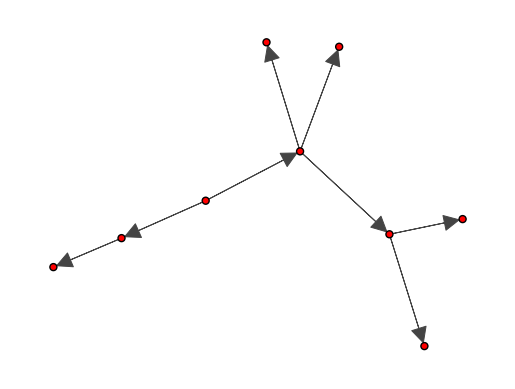

In [125]:

#cluster_index = 10
#nodes_subgraph = [v.index for v in g.vs if wcc.membership[v.index] == cluster_index]
component = g.subgraph(1)
#print(wcc.sizes())
#print(component)
fig, ax = plt.subplots()
ig.plot(
    wcc.subgraph(1),
    target=ax,
    palette=ig.RainbowPalette(),
    vertex_size=7,
    edge_width=0.7
)
plt.show()

## select the esges

ModuleNotFoundError: No module named 'PyVis'

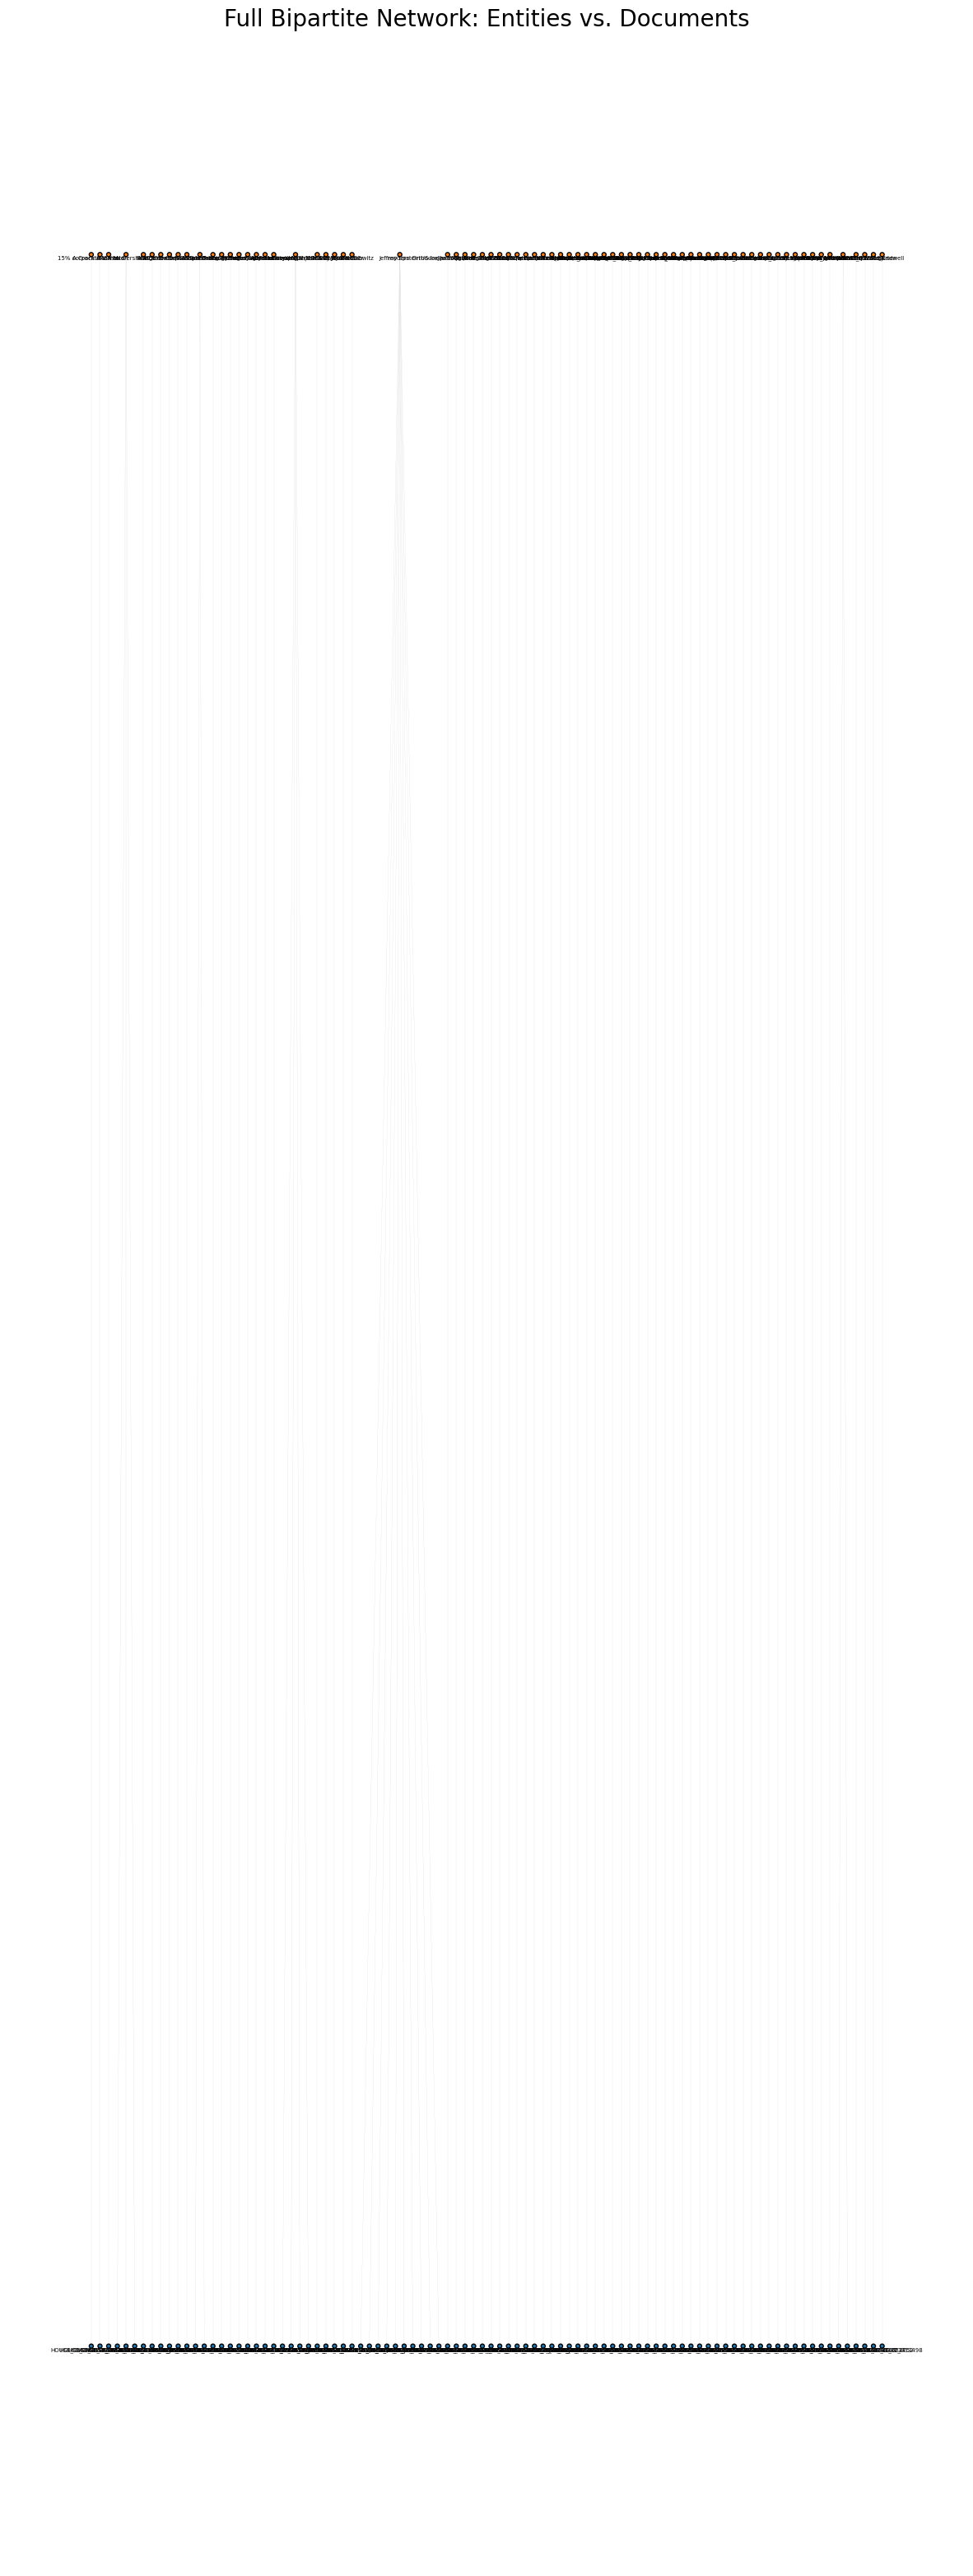

In [13]:
num_edges = g_bi.ecount()
sample_size = max(1, int(0.0005 * num_edges)) # Ensure at least 1 edge
sampled_edges = random.sample(range(num_edges), sample_size)
sub = g_bi.subgraph_edges(sampled_edges, delete_vertices=True)

# 1. Generate the Bipartite Layout on the FULL graph
# igraph uses the boolean 'type' attribute to put False on one side, True on the other


layout = sub.layout_bipartite(hgap=30, vgap=1)

# 2. Define Colors
# Orange for Entities (type == False), Blue for Documents (type == True)
colors = ["#FF7F0E" if t == False else "#1F77B4" for t in sub.vs["type"]]

# 3. Create a massive figure canvas
# 15 wide, 40 tall gives the vertical parallel lines room to breathe
fig, ax = plt.subplots(figsize=(15, 40)) 

# 4. Plot the graph
ig.plot(
    sub,
    target=ax,
    layout=layout,
    vertex_size=5,          # Very small nodes to prevent overlap
    vertex_color=colors,
    vertex_label=sub.vs["name"],
    vertex_label_size=5,    # Very small text
    vertex_label_dist=1.2,  # Pushes labels slightly outside the nodes
    edge_width=0.1,         # Extremely thin edges so you can see through the mass
    edge_color="#E0E0E0",   # Very light grey edges
    edge_arrow_size=0.2
)

ax.set_title("Full Bipartite Network: Entities vs. Documents", fontsize=20)
plt.axis('off') # Hides the axes box for a cleaner look
plt.show()

In [70]:
## Let's define the undirected version of it 
num_edges = g_bi.ecount()
sample_size = int(0.05 * num_edges)

sampled_edges = random.sample(range(num_edges), sample_size)

sub = g_bi.subgraph_edges(sampled_edges, delete_vertices=True)

layout = sub.layout("fr")  # Fruchterman-Reingold

ig.plot(
    sub,
    layout=layout,
    vertex_size=5,
    edge_arrow_size=0.2,
    bbox=(800, 800)
)

### Steps for today


- See what is unconsistent with the two different ways to simplify the graph and point that out
- Define the two projected graphs (We include here the simple version of our multigraph)
- define the graphs without Epstein
- Compute the standard statistics

- Try to learn streamlit or react-to-go with rust and D3 ()
### The presentation 

- What are the epstein files, who has released them, and in which format they were released

- How they where parsed (a zoo of github pages has appeared, the parsing is usually fine). Explain the difficulties of extrdacting info from emails. We use this dataset

- Explain the goal. Here Many studies can be performed and we have to give (and even choose!) the data having in mind an aim (this slide should be at the beginning). Either being the lawyer of Chomsky, i.e., find statistics that can be used to distinguish Chomsky and Prince Andrew, counterterrorism, historians

- Chomsky vs Prince Andrew slide

- Examples of similar studies: Data against Paul Revere 

- Massive document disclosure studies

- Graph Overview and Metric Explaination; 

- Statistical difficulties: Granularity of the data, 


### Future work 
- Save in neo4j the graphs
 

In [1]:
#Let's take a subgraph and plot it 
net = Network(height="750px", width="100%", directed=True)

# Add nodes
for v in sub.vs:
    title = f"Name: {v['name']}<br>Degree: <br>Betweenness:"
    net.add_node(v.index, label=v["name"], title=title)

# Add edges
for e in sub.es:
    # Add edge metadata if exists
    edge_title = ""
    for attr in [ "action"]:
        if attr in e.attributes():
            edge_title += f"{attr}: {e[attr]}<br>"
    net.add_edge(e.source, e.target, title=edge_title)


# Force-directed layout
net.force_atlas_2based()

# Save and render in Streamlit
net.save_graph("subgraph.html")
HtmlFile = open("subgraph.html", 'r', encoding='utf-8')
components.html(HtmlFile.read(), height=800, width=1000)

NameError: name 'Network' is not defined

In [31]:
utl.stampa_info_doc(documents, triples,'HOUSE_OVERSIGHT_027594')# 'HOUSE_OVERSIGHT_022445') #'HOUSE_OVERSIGHT_017088_part7')

-------------------------HOUSE_OVERSIGHT_027594-------------------------

******************************One Sentence Summary******************************
An SMS/iChat message exchange between Jeffrey Epstein (jeeitunes@gmail.com) and an unnamed recipient discussing international political developments, geopolitical strategy, travel plans, and media appearances from March 9-31, 2019.
********************************************************************************


********************************************************************************************************************************************************************************************************************************************************** Information *************************
Category: mixed_document
Data Range: From 2019-03-09 to 2019-03-31
********************************************************************************


-------------------------Parsed Relations-------------------------

We have found 107 seman

In [12]:
def compute_and_store_metrics(g):
    """
    Computes a wide array of node and edge metrics for a directed graph
    and stores them directly inside the igraph object as attributes.
    """
    print(f"Starting metrics computation for graph with {g.vcount()} nodes and {g.ecount()} edges...\n")
    total_start = time.time()

    # ==========================================
    # 1. NODE DEGREES
    # ==========================================
    t0 = time.time()
    g.vs["degree_all"] = g.degree(mode="all")
    g.vs["degree_in"] = g.degree(mode="in")
    g.vs["degree_out"] = g.degree(mode="out")
    print(f"[Time] Degrees (In/Out/All): {time.time() - t0:.2f} s")

    # ==========================================
    # 2. CENTRALITIES (The Heavy Lifters)
    # ==========================================
    t0 = time.time()
    g.vs["pagerank"] = g.pagerank(directed=True)
    print(f"[Time] PageRank: {time.time() - t0:.2f} s")

    t0 = time.time()
    # Warning: Betweenness can take a minute on 180k edges. 
    g.vs["betweenness"] = g.betweenness(directed=True)
    print(f"[Time] Node Betweenness: {time.time() - t0:.2f} s")

    t0 = time.time()
    g.vs["eigenvector"] = g.eigenvector_centrality(directed=True)
    print(f"[Time] Eigenvector Centrality: {time.time() - t0:.2f} s")
    # ==========================================
    # 3. HUBS & AUTHORITIES (HITS)
    # ==========================================
    t0 = time.time()
    
    # Check if the graph is strictly bipartite before running HITS
    if g.is_bipartite():
        print("Graph is bipartite. Computing HITS...")
        # Entities will naturally score high here
        g.vs["hub_score"] = g.hub_score()
        # Documents will naturally score high here
        g.vs["authority_score"] = g.authority_score()
        print(f"[Time] HITS (Hubs & Authorities): {time.time() - t0:.2f} s")
    else:
        print("Graph is NOT perfectly bipartite. Skipping HITS...")
        # Fill with None so your dataframe doesn't break later
        g.vs["hub_score"] = [None] * g.vcount()
        g.vs["authority_score"] = [None] * g.vcount()

    # ==========================================
    # 4. STRUCTURAL METRICS
    # ==========================================
    t0 = time.time()
    # Coreness (k-core decomposition): measures how deeply embedded a node is
    g.vs["coreness"] = g.coreness(mode="all")
    print(f"[Time] Coreness (k-core): {time.time() - t0:.2f} s")

    t0 = time.time()
    # Local Clustering Coefficient (transitivity). 
    # mode="zero" ensures nodes with degree < 2 get a score of 0 instead of NaN
    g.vs["clustering_coeff"] = g.transitivity_local_undirected(mode="zero")
    print(f"[Time] Local Clustering Coefficient: {time.time() - t0:.2f} s")

    # ==========================================
    # 5. EDGE METRICS
    # ==========================================
    t0 = time.time()
    g.es["edge_betweenness"] = g.edge_betweenness(directed=True)
    print(f"[Time] Edge Betweenness: {time.time() - t0:.2f} s")
    
    # ------------------------------------------
    print(f"\n✅ All metrics computed and stored in {time.time() - total_start:.1f} seconds total.")
    return g

# Run it on your graph!
g_bi = utl.extract_main_component(g_bi)
g_bi = compute_and_store_metrics(g_bi)

Analyzing components for graph with 67930 nodes...
  > Largest component: 65363 nodes
  > Second largest component: 46 nodes
Starting metrics computation for graph with 65363 nodes and 181228 edges...

[Time] Degrees (In/Out/All): 0.01 s
[Time] PageRank: 0.05 s
[Time] Node Betweenness: 231.44 s
[Time] Eigenvector Centrality: 0.26 s
Graph is bipartite. Computing HITS...
[Time] HITS (Hubs & Authorities): 0.35 s
[Time] Coreness (k-core): 0.02 s
[Time] Local Clustering Coefficient: 0.04 s
[Time] Edge Betweenness: 305.31 s

✅ All metrics computed and stored in 537.5 seconds total.


/var/folders/0d/sy78600529zbft660xb6xvdm0000gn/T/ipykernel_16657/3429994262.py:31: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:103
  g.vs["eigenvector"] = g.eigenvector_centrality(directed=True)
/var/folders/0d/sy78600529zbft660xb6xvdm0000gn/T/ipykernel_16657/3429994262.py:42: RuntimeWarning: More than 30% of hub or authority scores are zeros. The presence of zero values indicates that the solution is not unique, thus the returned result may not be meaningful. Location: src/centrality/hub_authority.c:81
  g.vs["hub_score"] = g.hub_score()
/var/folders/0d/sy78600529zbft660xb6xvdm0000gn/T/ipykernel_16657/3429994262.py:44: RuntimeWarning: More than 30% of hub or authority scores are zeros. The presence of zero values indicates that the solution is not unique, thus the returned result may not be meaningful. Lo

In [10]:
g = utl.extract_main_component(g)
g = utl.compute_and_store_metrics(g)

Analyzing components for graph with 52238 nodes...
  > Largest component: 36618 nodes
  > Second largest component: 35 nodes
Starting metrics computation for graph with 36618 nodes and 81847 edges...

[Time] Degrees (In/Out/All): 0.01 s
[Time] PageRank: 0.02 s
[Time] Node Betweenness: 20.27 s
[Time] Eigenvector Centrality: 0.13 s
Graph is NOT perfectly bipartite. Skipping HITS...
[Time] Coreness (k-core): 0.01 s
[Time] Local Clustering Coefficient: 0.01 s


/Users/alessandrogubbiotti/Data-Wrangling-Project/src/my_utils.py:376: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:103
  g.vs["eigenvector"] = g.eigenvector_centrality(directed=True)


[Time] Edge Betweenness: 37.31 s

✅ All metrics computed and stored in 57.8 seconds total.


In [14]:
print(g.summary())

IGRAPH DN-- 36618 81847 -- 
+ attr: avg_path_length (g), density (g), diameter (g), infomap_modularity (g), louvain_modularity (g), num_edges (g), num_vertices (g), reciprocity (g), infomap_cluster (v), louvain_cluster (v), name (v), action (e), doc_id (e)


In [10]:
g = utl.extract_main_component(g)
g = utl.compute_global_statistics(g)

Analyzing components for graph with 52238 nodes...
  > Largest component: 36618 nodes
  > Second largest component: 35 nodes

--- Computing Global Graph Statistics ---
[Time] Basic counts: 0.00 s
[Time] Density: 0.00 s
[Time] Reciprocity: 0.00 s
Calculating Average Path Length (this may take a minute...)
[Time] Average Path Length: 4.81 s
Calculating Diameter (this may take a minute...)
[Time] Diameter: 5.21 s
✅ Global Statistics computed and stored in 10.0 s total.


In [13]:
g = utl.compute_communities(g)


--- Starting Community Detection for 36618 nodes ---
[Time] Laplacian FAILED: 'Graph' object has no attribute 'get_laplacian'
[Time] Graph undirected conversion (for Louvain): 0.06 s
[Time] Louvain Community Detection: 0.40 s
[Time] Infomap Community Detection: 8.47 s
✅ Community Detection complete in 8.9 s total.


In [16]:
g = utl.clean_communities_and_bisect(g)

Cleaning communities (min_size=50) and applying bisection...
  > Laplacian Split: 0 nodes (1) | 0 nodes (0)
  > Infomap: Kept 79 major communities.
  > All other nodes assigned to noise cluster (-1).
